## 統計的にdata2vecから得られる特徴表現を調査したい！

## 準備

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import numpy as np
import torch
import pandas as pd
import json
import h5py
from pathlib import Path
import copy
from omegaconf import OmegaConf
import hydra
from pretrain.models import BaseModel as PretrainModel


os.chdir(
    "/workspaces/"
)  # 変更したいディレクトリのパスを指定

# frameworks = ["data2vec", "mlm", "rnafm", "rinalmo"]
frameworks = ["data2vec", "mlm", "rinalmo"]
framework_colors = {
    "data2vec": "orange",
    "mlm": "blue",
    "rinalmo": "gray",
}
nucleotides = ["A", "C", "G", "U"]
family = [
    "5s",
    "16s",
    "23s",
    "grp1",
    "RNaseP",
    "srp_long",
    "srp_short",
    "telomerase",
    "tmRNA",
    "tRNA",
]

framework_path_dict = {
    "data2vec": Path(
        "./data/pretrain_results/nqdata2vec/20250827T062459/mynqd2v_ArchiveII_student.h5"
    ),
    "mlm": Path("./data/pretrain_results/MLM/20250801T085843/mymlm_ArchiveII.h5"),
    "rinalmo": Path("./data/embeddings/RiNALMo_ArchiveII.h5"),
}

archiveII_file = pd.read_csv("./data/SS_data/ArchiveII.csv")

# シード値の設定
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# 予測対象とする配列を選択

metadata = {
    "id": "",
    "data2vec_score": 0.0,
    "mlm_score": 0.0,
}

fam_representatives = {}

# compare_kinds = {
#     "both_high": copy.deepcopy(metadata),
#     "both_low": copy.deepcopy(metadata),
#     "d2v_than_mlm": copy.deepcopy(metadata),
#     "mlm_than_d2v": copy.deepcopy(metadata),
# }

# fam_representatives = {fam: copy.deepcopy(compare_kinds) for fam in family}

# both_high_or_low_csv = pd.read_csv(
#     "../data/bpseq_outputs/ArchiveII_famfold/both_high/best_rna_both_high.csv"
# )
# mlm_vs_d2v_csv = pd.read_csv(
#     "../data/bpseq_outputs/ArchiveII_famfold/mlm_than_d2v/best_rna_mlm_than_d2v.csv"
# )

# for fam in family:
#     fam_csv = pd.read_csv(f"../data/SS_data/archiveII_famfold/{fam}/test.csv")

#     both_df = both_high_or_low_csv[both_high_or_low_csv["seq_ids"].isin(fam_csv["id"])]
#     vs_df = mlm_vs_d2v_csv[mlm_vs_d2v_csv["seq_ids"].isin(fam_csv["id"])]

#     fam_representatives[fam]["both_high"]["id"] = both_df.iloc[0]["seq_ids"]
#     fam_representatives[fam]["both_high"]["mlm_score"] = both_df.iloc[0]["score_1"]
#     fam_representatives[fam]["both_high"]["data2vec_score"] = both_df.iloc[0]["score_2"]

#     fam_representatives[fam]["both_low"]["id"] = both_df.iloc[-1]["seq_ids"]
#     fam_representatives[fam]["both_low"]["mlm_score"] = both_df.iloc[-1]["score_1"]
#     fam_representatives[fam]["both_low"]["data2vec_score"] = both_df.iloc[-1]["score_2"]

#     fam_representatives[fam]["mlm_than_d2v"]["id"] = vs_df.iloc[0]["seq_ids"]
#     fam_representatives[fam]["mlm_than_d2v"]["mlm_score"] = vs_df.iloc[0]["score_1"]
#     fam_representatives[fam]["mlm_than_d2v"]["data2vec_score"] = vs_df.iloc[0][
#         "score_2"
#     ]

#     fam_representatives[fam]["d2v_than_mlm"]["id"] = vs_df.iloc[-1]["seq_ids"]
#     fam_representatives[fam]["d2v_than_mlm"]["mlm_score"] = vs_df.iloc[-1]["score_1"]
#     fam_representatives[fam]["d2v_than_mlm"]["data2vec_score"] = vs_df.iloc[-1][
#         "score_2"
#     ]


In [ ]:
# アテンション評価関数の定義
def bp2matrix(L, base_pairs):
    matrix = np.zeros((L, L), dtype=np.float16)
    if base_pairs != []:
        # base pairs are 1-based
        bp = np.array(base_pairs) - 1
        matrix[bp[:, 0], bp[:, 1]] = 1
        matrix[bp[:, 1], bp[:, 0]] = 1

    return matrix


def assess_attention(attn, gt, n_heads=20, n_layers=12):
    """
    Assess the quality of attention maps against ground truth contact maps.
    Args:
        attn (np.Ndarray): Attention maps of shape (n_heads*n_layers, L, L).
        gt (np.Ndarray): Ground truth contact map of shape (L, L).
    Returns:
        float: the percentage of attention weights that indicate the pairing of structural tokens within each attention head of the architecture
    """

    max_score = 0.0
    for hl in range(n_heads * n_layers):
        score = np.sum(attn[hl] * gt) / np.sum(attn[hl])
        if score > max_score:
            max_score = score.astype(float)

    return max_score

In [ ]:
# 表現学習モデルの準備
import pretrain.dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {f"{framework_name}": None for framework_name in frameworks}

for framework_name in frameworks:
    model_path = framework_path_dict[framework_name]
    if not model_path.exists():
        raise FileNotFoundError(f"Pretrain model path {model_path} does not exist.")

    cfg_path = model_path / f"train_config/.hydra/config.yaml"
    cfg = OmegaConf.load(cfg_path)
    cfg.common.batch_size = 1

    model: PretrainModel = hydra.utils.instantiate(
        cfg.framework,
        padding_idx=cfg.dataset.tokens.index("<pad>"),
        num_tokens=len(cfg.dataset.tokens),
        experiment_cfg=cfg.experiment,
        device=device
    )

    ## 事前学習モデルの重みの読み込み
    weight = f"weight_150000.pth"
    model._load_state_dict(torch.load(model_path / weight, map_location=device))
    
    models[framework_name] = {
        "model": model,
        "cfg": cfg,
        "dataloader": pretrain.dataset.create_dataloader(config=cfg, split="test")
    }

In [ ]:
# メドイド法で選択した代表配列を追加

from Levenshtein import distance


def select_medoid(sequences: list) -> str:
    """
    配列リストからメドイド（他全配列への距離の総和が最小の配列）を返す
    """
    n = len(sequences)
    if n == 0:
        return None
    if n == 1:
        return sequences[0]

    min_total_dist = float("inf")
    medoid_seq = None

    # 各配列について、他の全ての配列との距離の合計を計算
    for i, seq_i in enumerate(sequences):
        total_dist = 0
        for j, seq_j in enumerate(sequences[i + 1 :], start=i + 1):
            # 配列間の編集距離を加算
            total_dist += distance(str(seq_i), str(seq_j))

        # 合計距離が最小のものを更新
        if total_dist < min_total_dist:
            min_total_dist = total_dist
            medoid_seq = seq_i

    return medoid_seq


for fam in family:
    fam_csv = pd.read_csv(f"./data/SS_data/archiveII_famfold/{fam}/test.csv")
    sequences = fam_csv["sequence"].tolist()
    medoid_seq = select_medoid(sequences)

    seq_id = fam_csv[fam_csv["sequence"] == medoid_seq]["id"].values[0]

    fam_representatives[fam]["medoid"] = {
        "id": seq_id,
    }

## 変異関係なくA, U, G, Cの表現を比較

In [ ]:
# 配列表現の抽出
family_representatives = {}
for framework_name in frameworks:
    if framework_name == "rinalmo":
        with h5py.File(framework_path_dict[framework_name], "r") as hdf:
            # 比較対象とする配列の読み込み
            family_representatives[framework_name] = {fam: {} for fam in family}
            for fam in family:
                seq_id = fam_representatives[fam]["id"]
                family_representatives[framework_name][fam] = {
                    "seq_id": seq_id,
                    "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                        "sequence"
                    ].values[0],
                    "representation": torch.from_numpy(hdf[seq_id][:]).requires_grad_(
                        False
                    ),
                }
    else:
        family_representatives[framework_name] = {fam: {} for fam in family}
        
        seq_list = [seq_id for fam in family for seq_id in fam_representatives[fam]["id"]]
        seq_dict = {fam: {} for fam in family}
        
        for fam in family:
            seq_dict[fam]["seq_id"] = fam_representatives[fam]["id"]
            for batch in models[framework_name]["dataloader"]:
                assert len(batch["seq_id"]) == 1, "Batch size should be 1 for representation extraction."
                batch_seq_id = batch["seq_id"][0]
                if batch_seq_id == seq_dict[fam]["seq_id"]:
                    seq_dict[fam]["batch"] = batch
                    break

        for fam, seq_info in seq_dict.items():
            seq_id = seq_info["seq_id"]
            representation = models[framework_name]["model"]._test(seq_info["batch"])["repr"] # B x L x E
            
            family_representatives[framework_name][fam] = {
                "seq_id": seq_id,
                "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                    "sequence"
                ].values[0],
                "representation": representation.squeeze(0).detach(),  # L x E
            }

Family: 5s
  compare_kind: medoid, Sequence ID: 5s_Streptomyces-griseus-1
  compare_kind: both_high, Sequence ID: 5s_Hydrurus-foetidus-1
  compare_kind: both_low, Sequence ID: 5s_Helicobacter-pylori-3
  compare_kind: d2v_than_mlm, Sequence ID: 5s_Nanoarchaeum-equitans-1
  compare_kind: mlm_than_d2v, Sequence ID: 5s_Nicotiana-tabacum-1


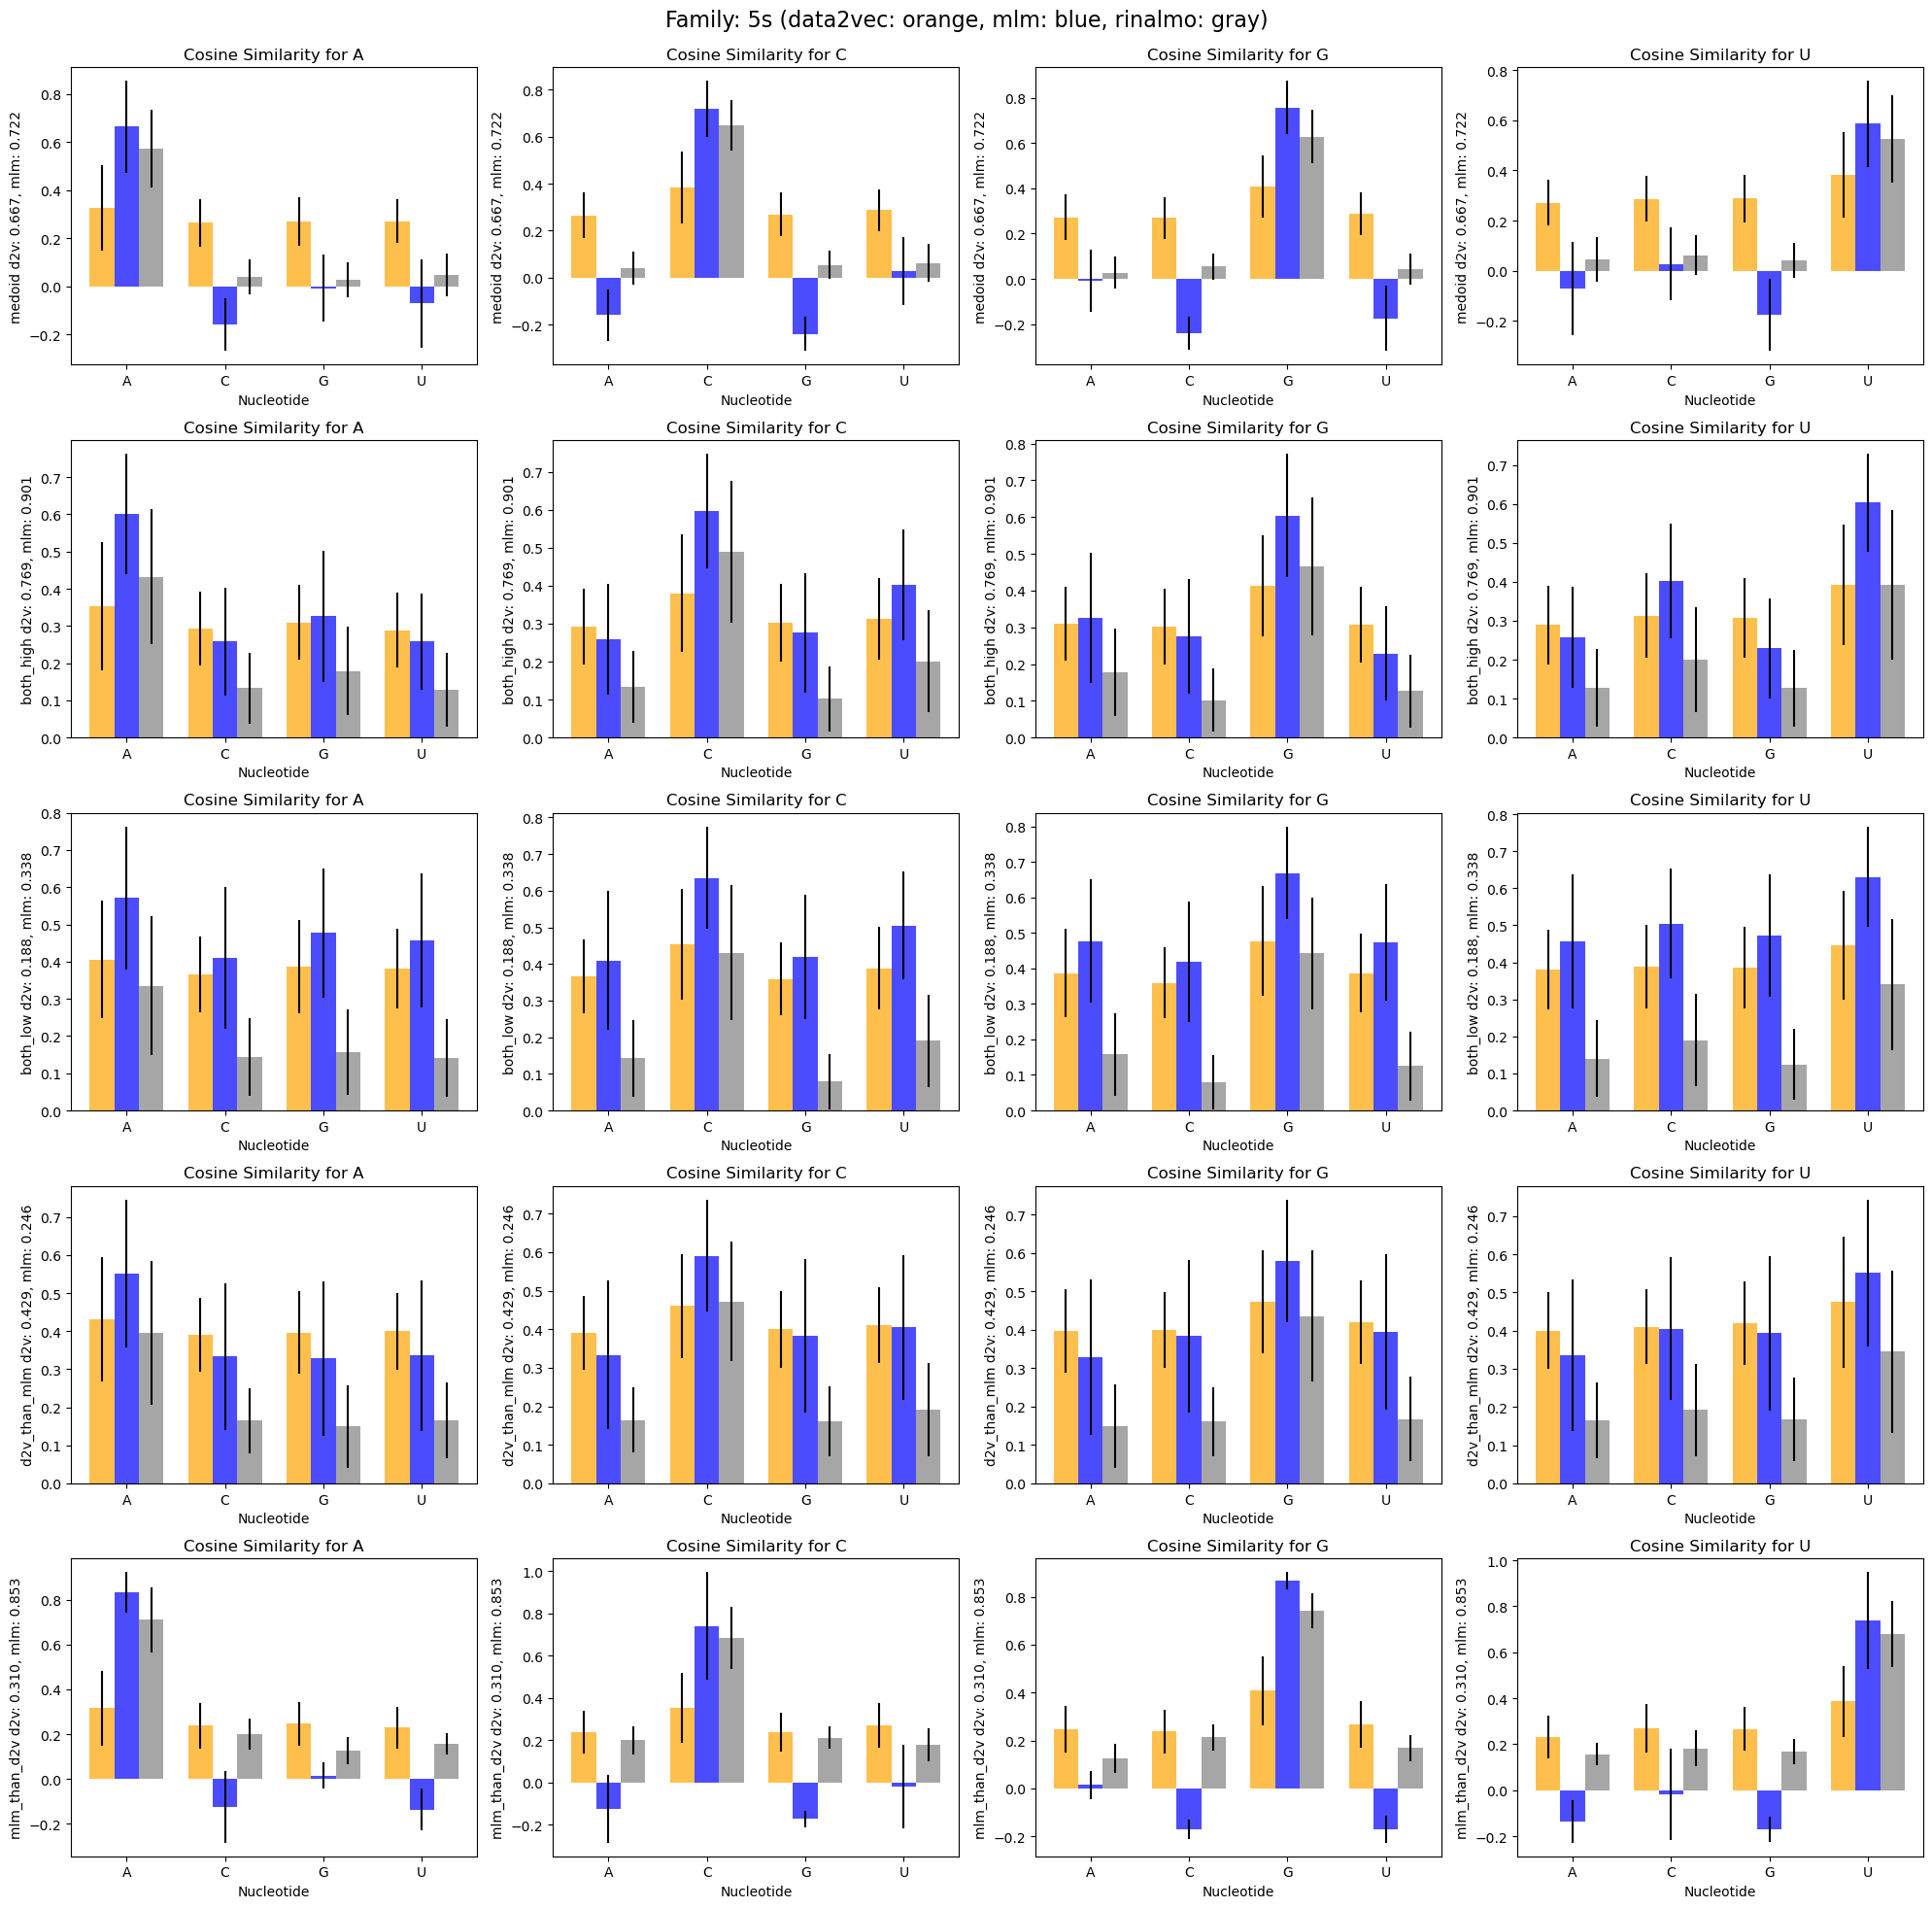

Family: 16s
  compare_kind: medoid, Sequence ID: 16s_T.maritima_domain3
  compare_kind: both_high, Sequence ID: 16s_H.volcanii_domain2
  compare_kind: both_low, Sequence ID: 16s_M.polymorpha_domain4
  compare_kind: d2v_than_mlm, Sequence ID: 16s_C.reinhardtii.mito_domain1
  compare_kind: mlm_than_d2v, Sequence ID: 16s_C.elegans_domain2


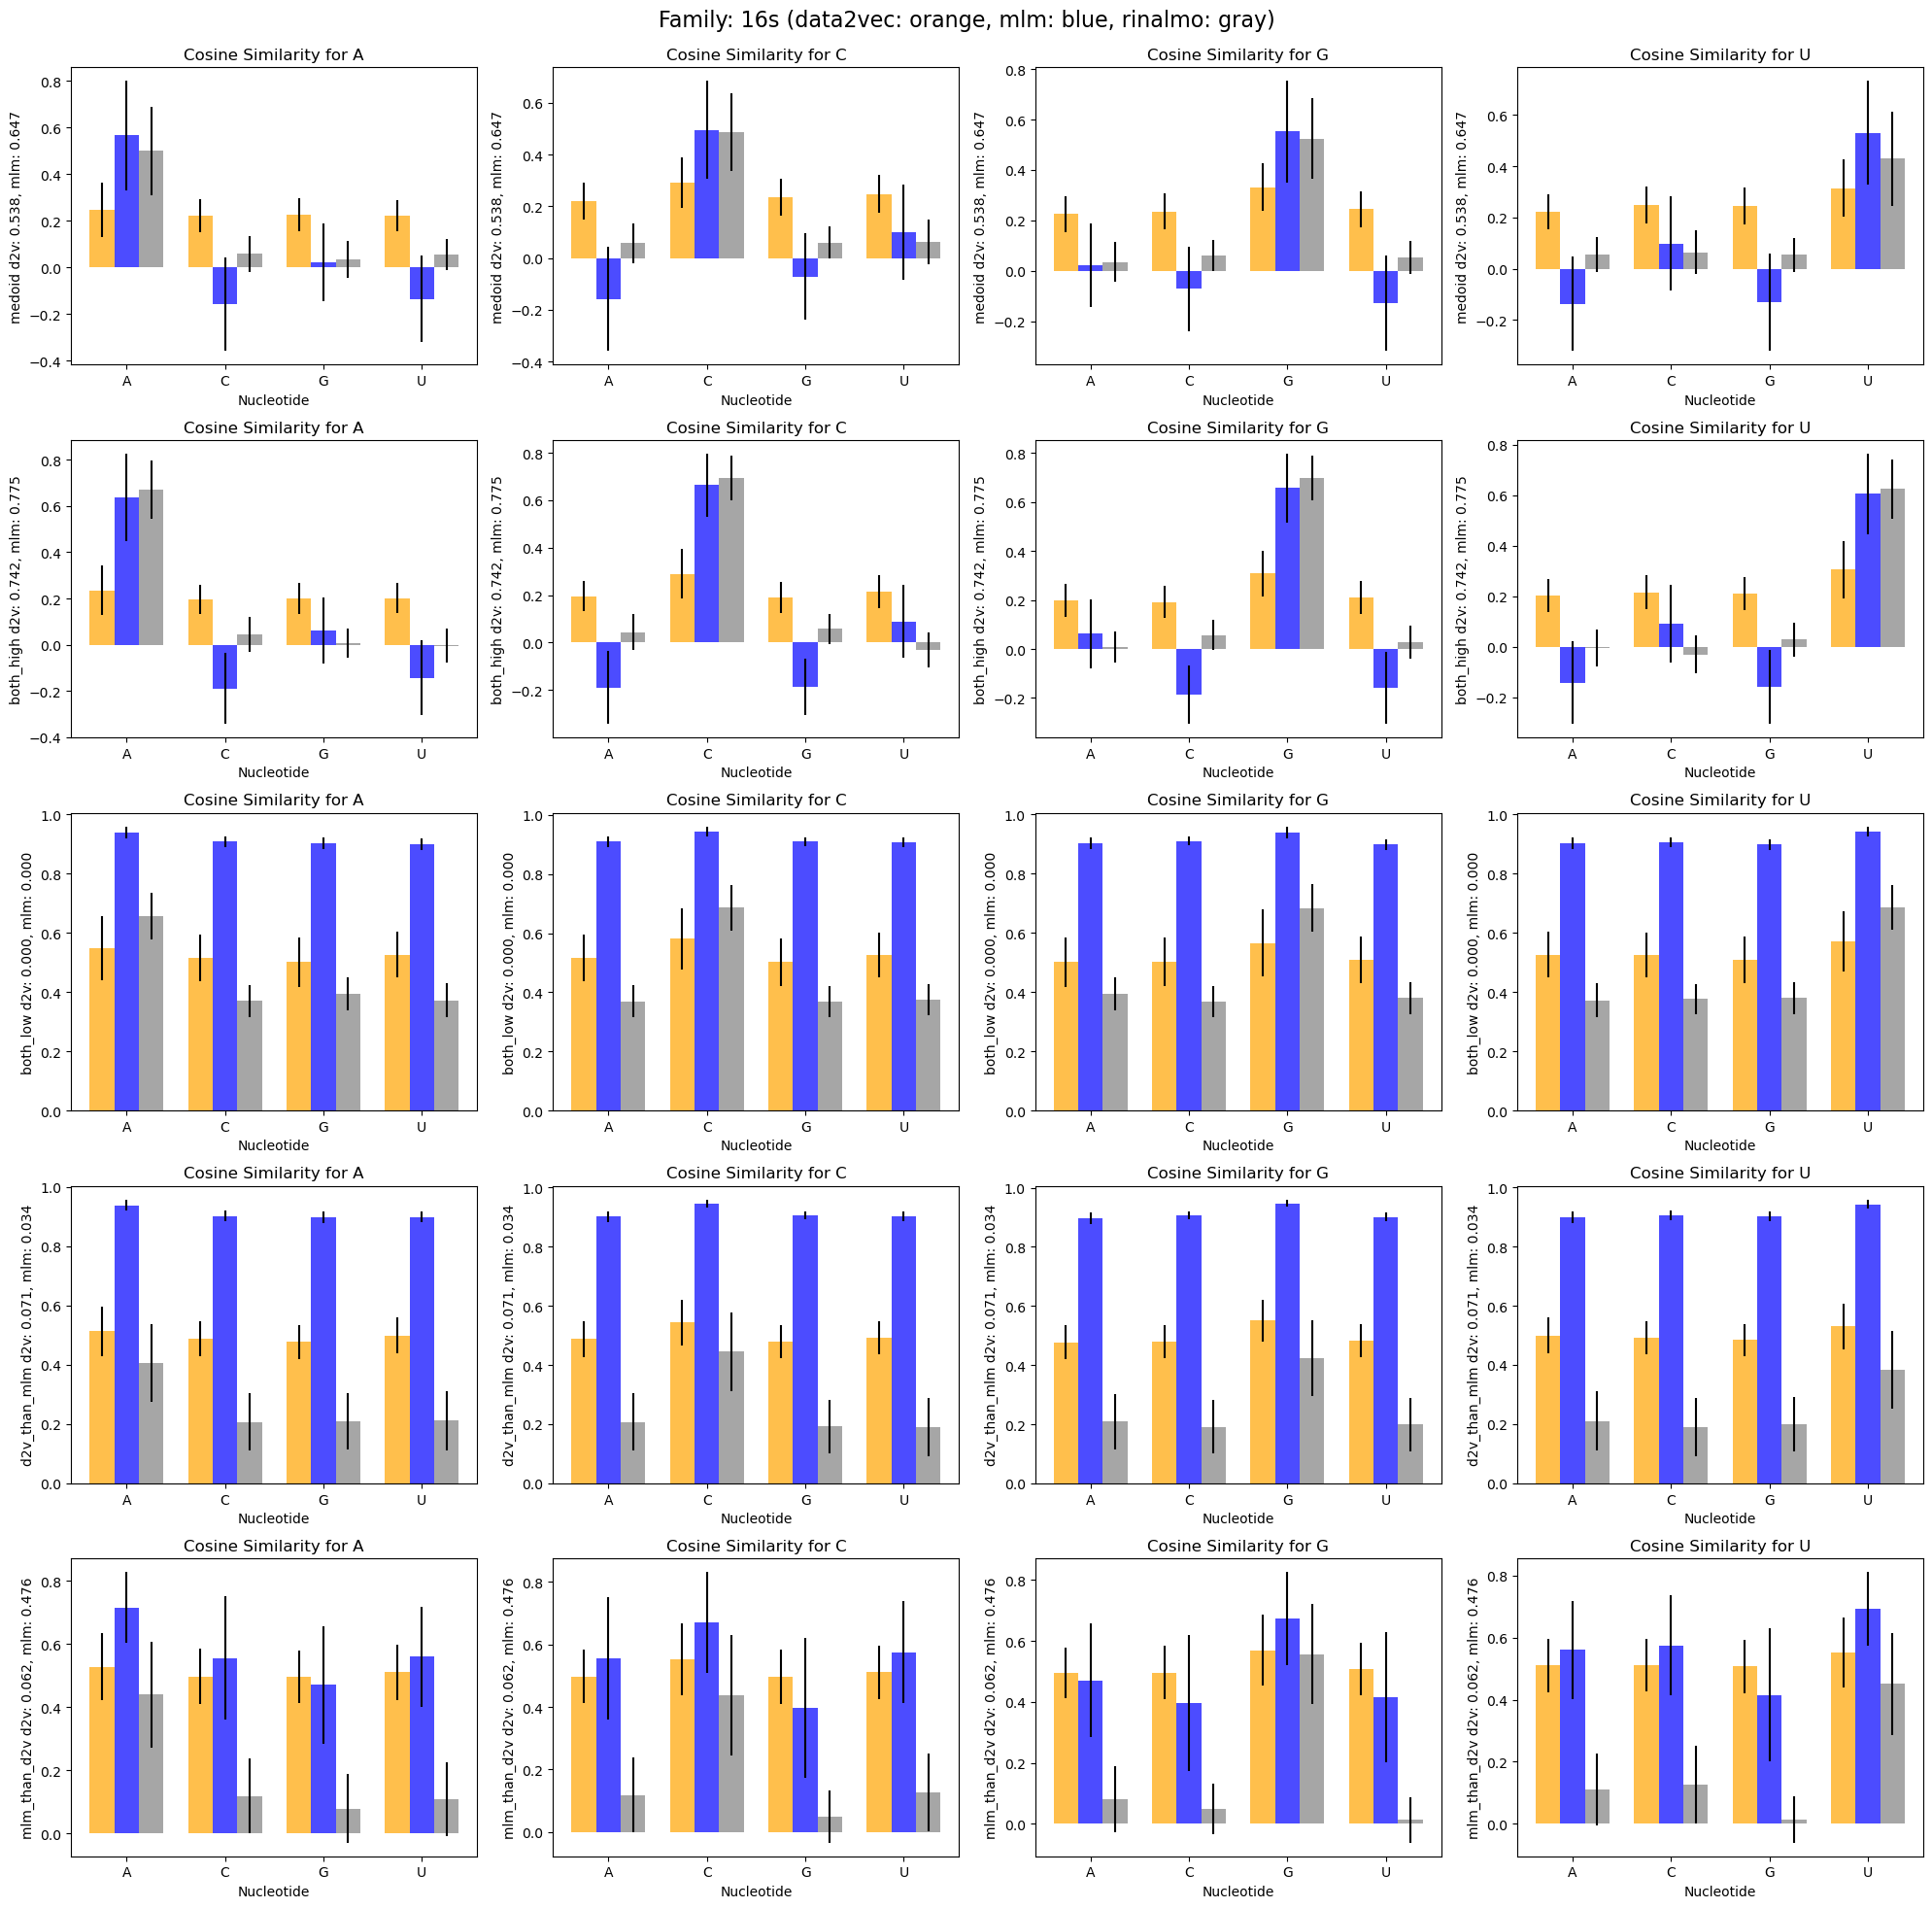

Family: 23s
  compare_kind: medoid, Sequence ID: 23s_H.pylori_domain4
  compare_kind: both_high, Sequence ID: 23s_B.subtilis_domain6
  compare_kind: both_low, Sequence ID: 23s_T.thermophilus_domain4
  compare_kind: d2v_than_mlm, Sequence ID: 23s_B.subtilis_domain3
  compare_kind: mlm_than_d2v, Sequence ID: 23s_S.aureus_domain4


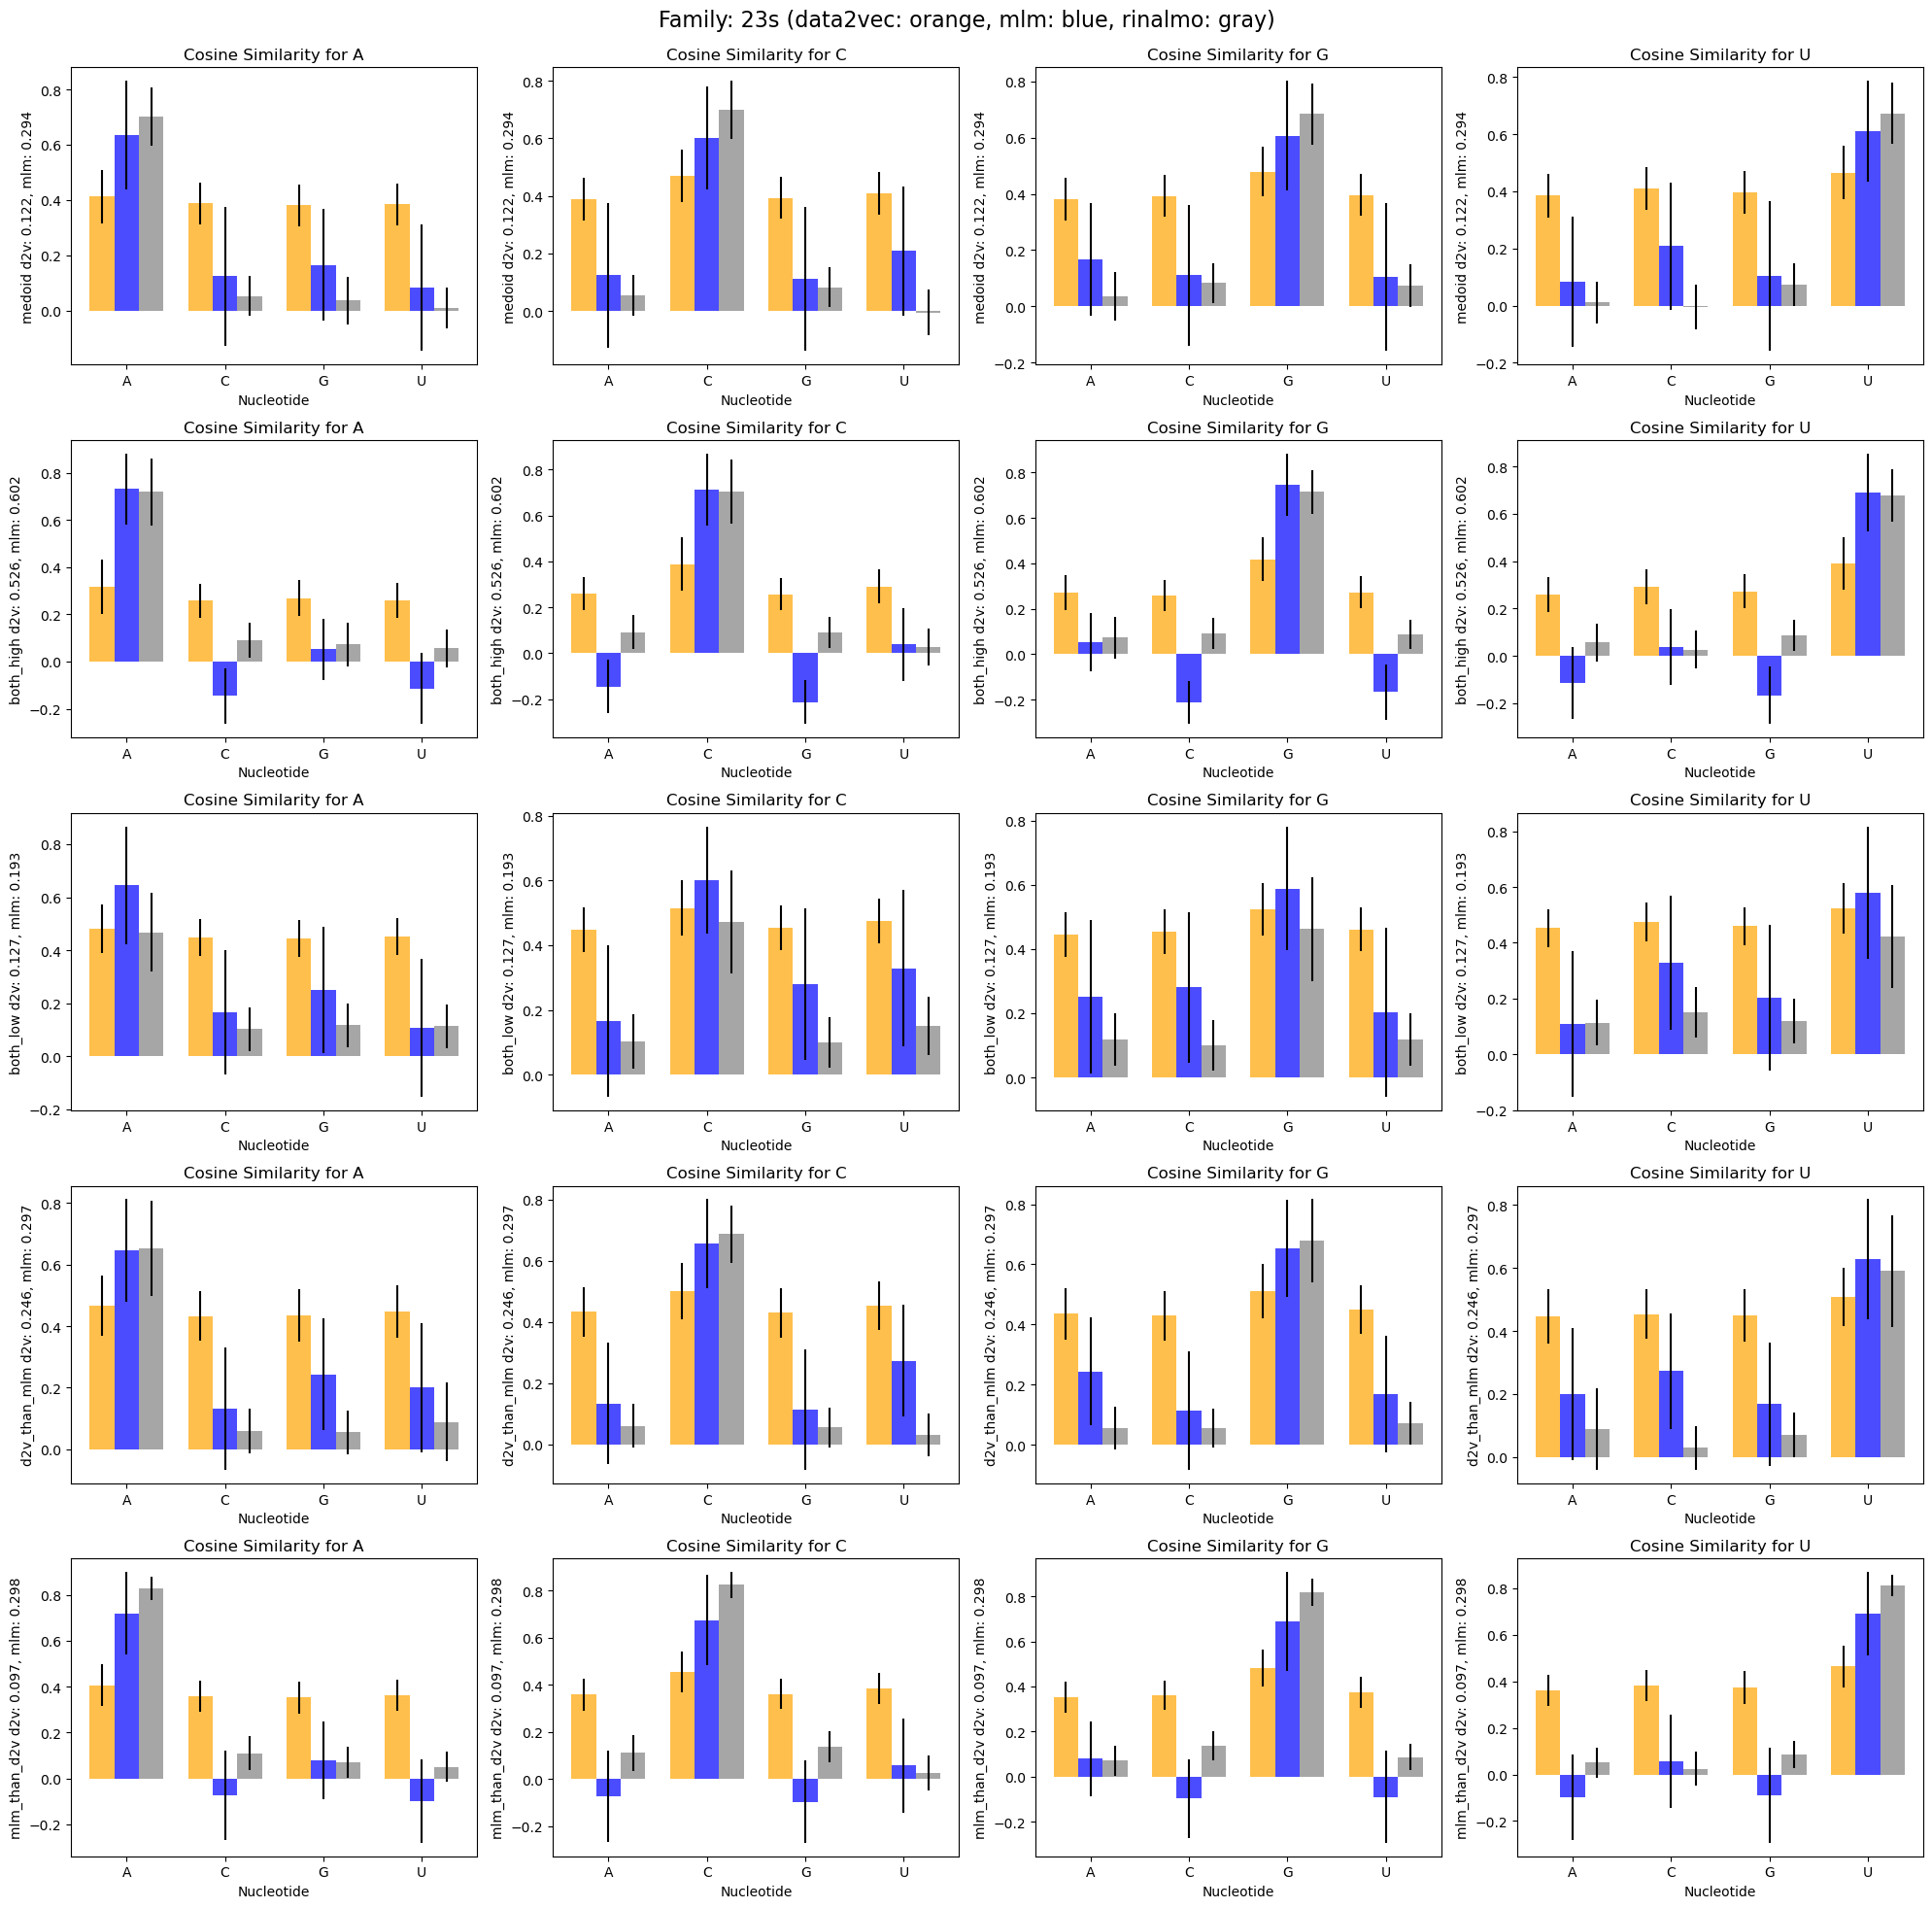

Family: grp1
  compare_kind: medoid, Sequence ID: grp1_a.I1.e.P.pachydermus.C1.SSU.943
  compare_kind: both_high, Sequence ID: grp1_a.I1.e.C.merochlorophea.UNK.SSU.1516
  compare_kind: both_low, Sequence ID: grp1_a.I1.e.L.dispersa.UNK.SSU.789
  compare_kind: d2v_than_mlm, Sequence ID: grp1_a.I1.e.S.paniceum.UNK.SSU.1210
  compare_kind: mlm_than_d2v, Sequence ID: grp1_a.I1.e.C.ellipsoidea.IAMC-87.C1.SSU.1506


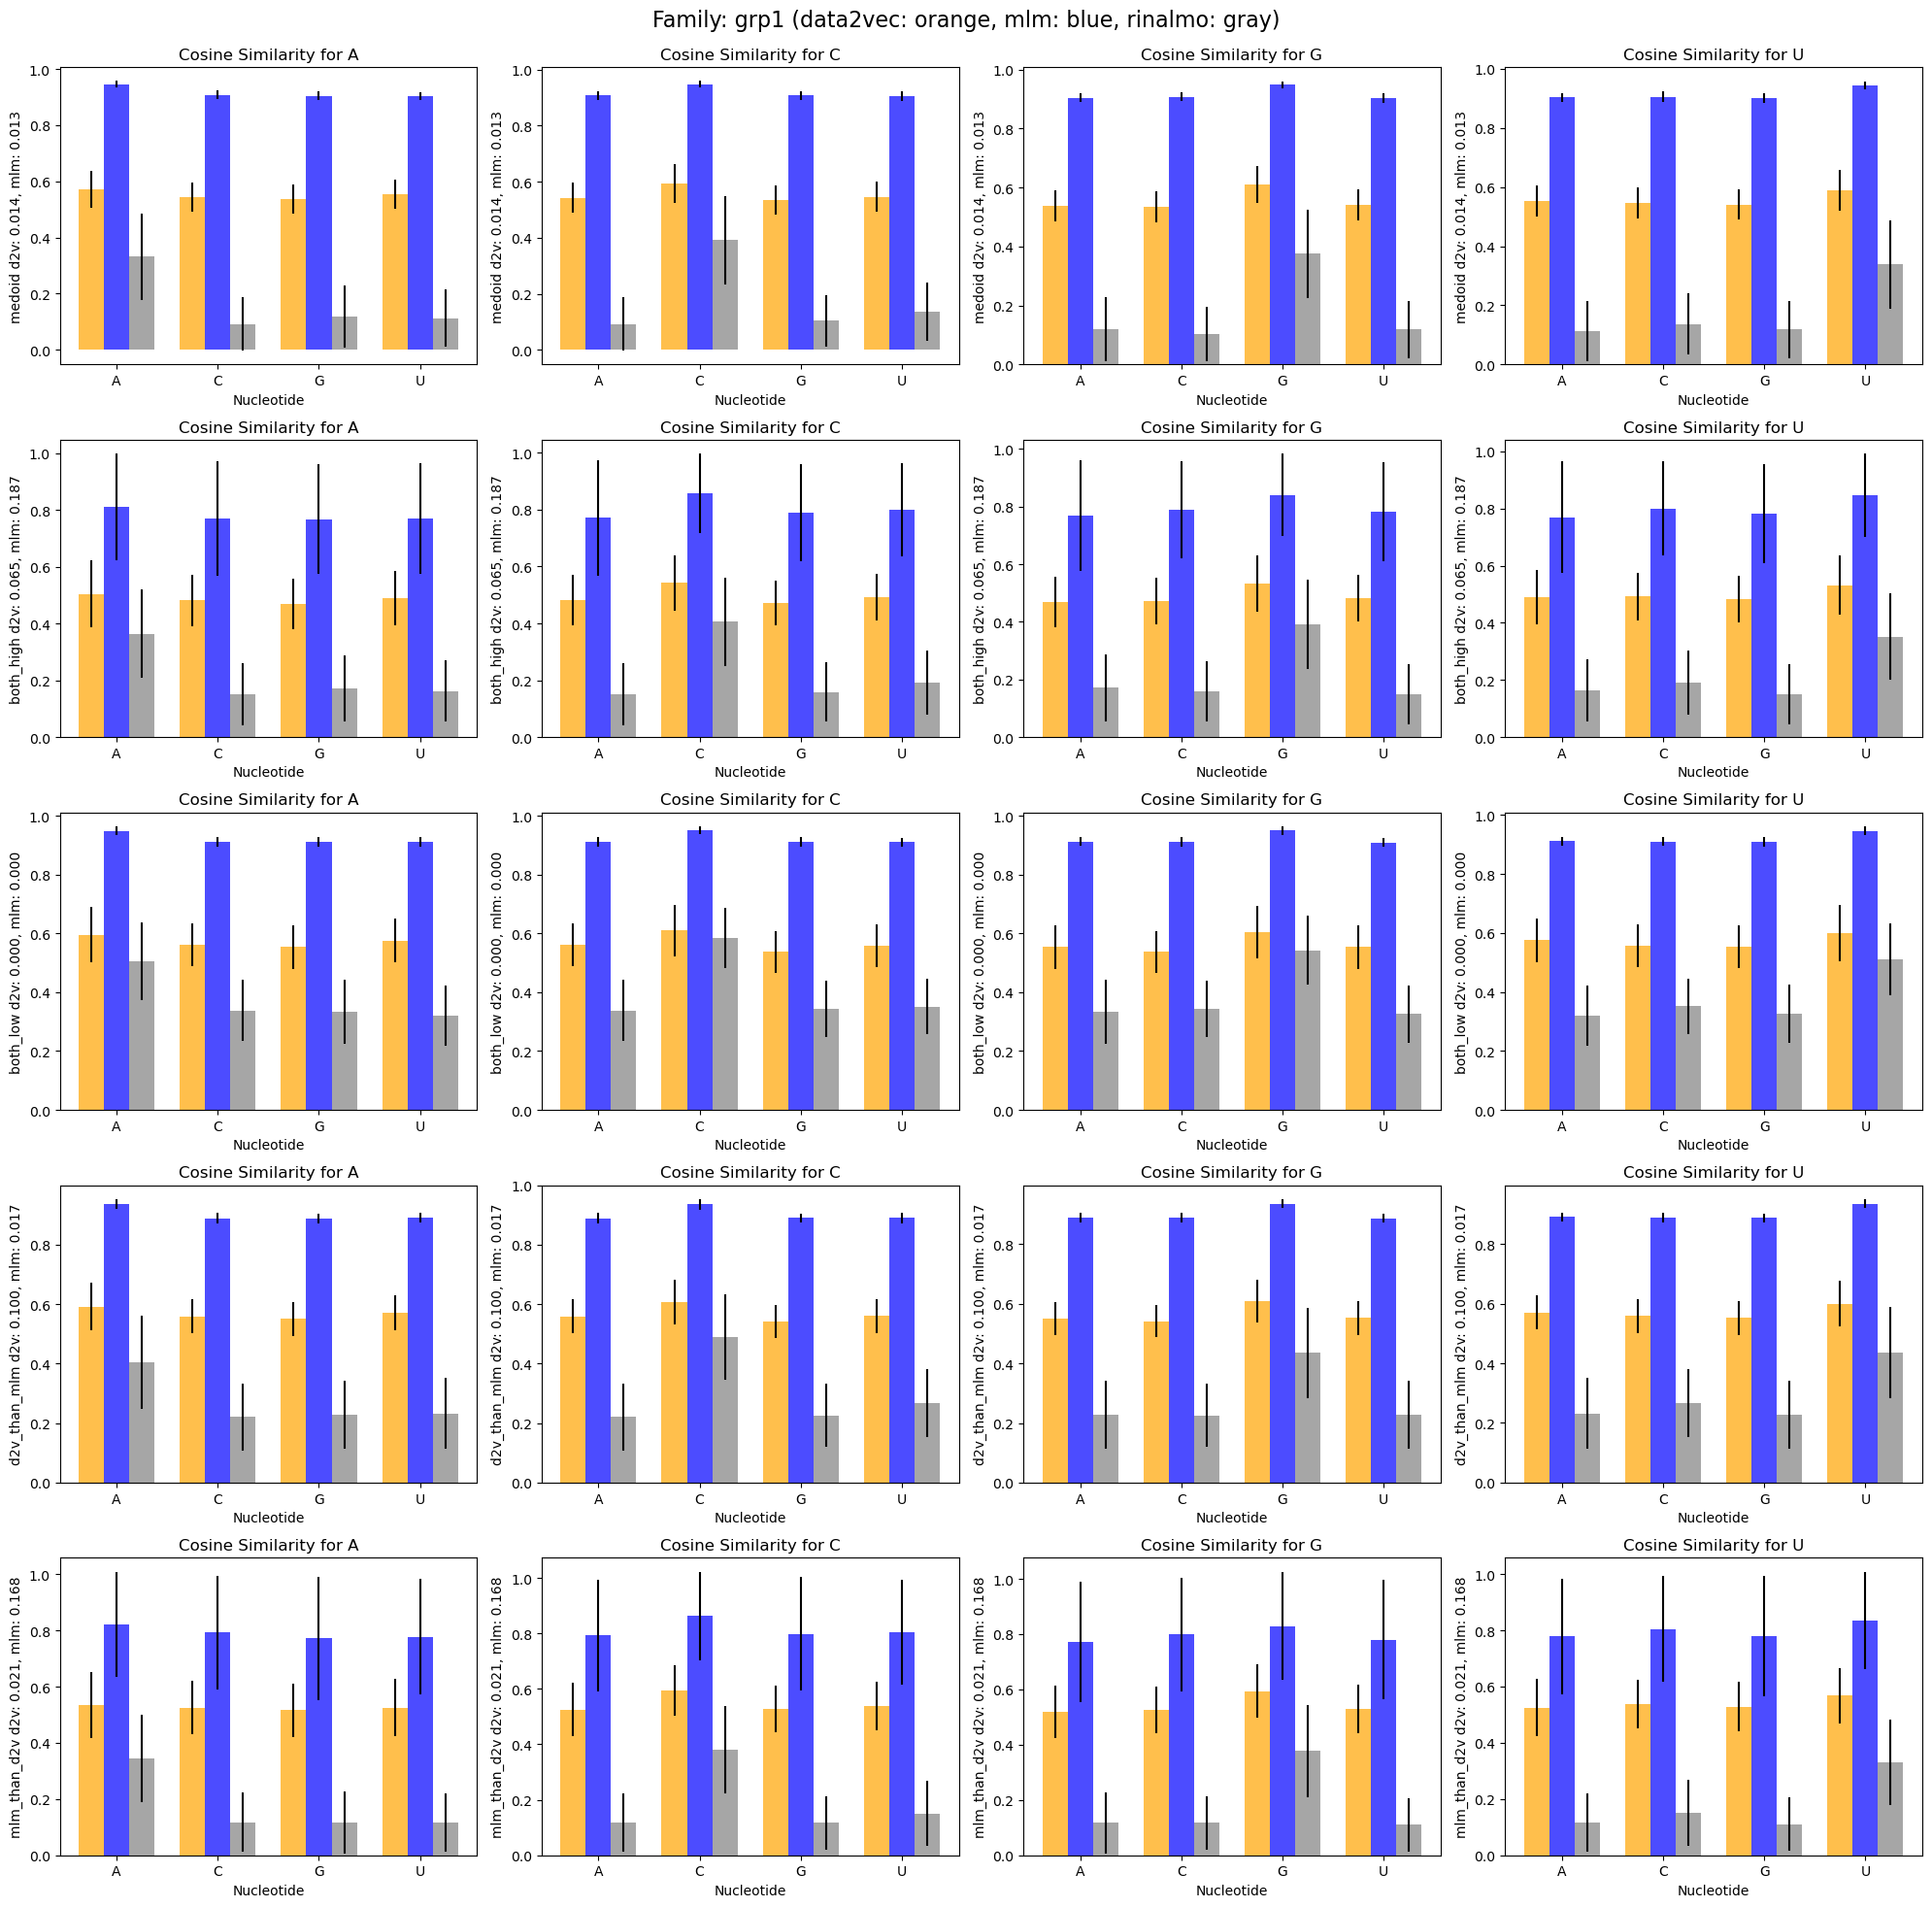

Family: RNaseP
  compare_kind: medoid, Sequence ID: RNaseP_M.avium
  compare_kind: both_high, Sequence ID: RNaseP_A.ferrooxidans-g
  compare_kind: both_low, Sequence ID: RNaseP_A.truei
  compare_kind: d2v_than_mlm, Sequence ID: RNaseP_Prochlorococcus-TATL2
  compare_kind: mlm_than_d2v, Sequence ID: RNaseP_U.urealyticum


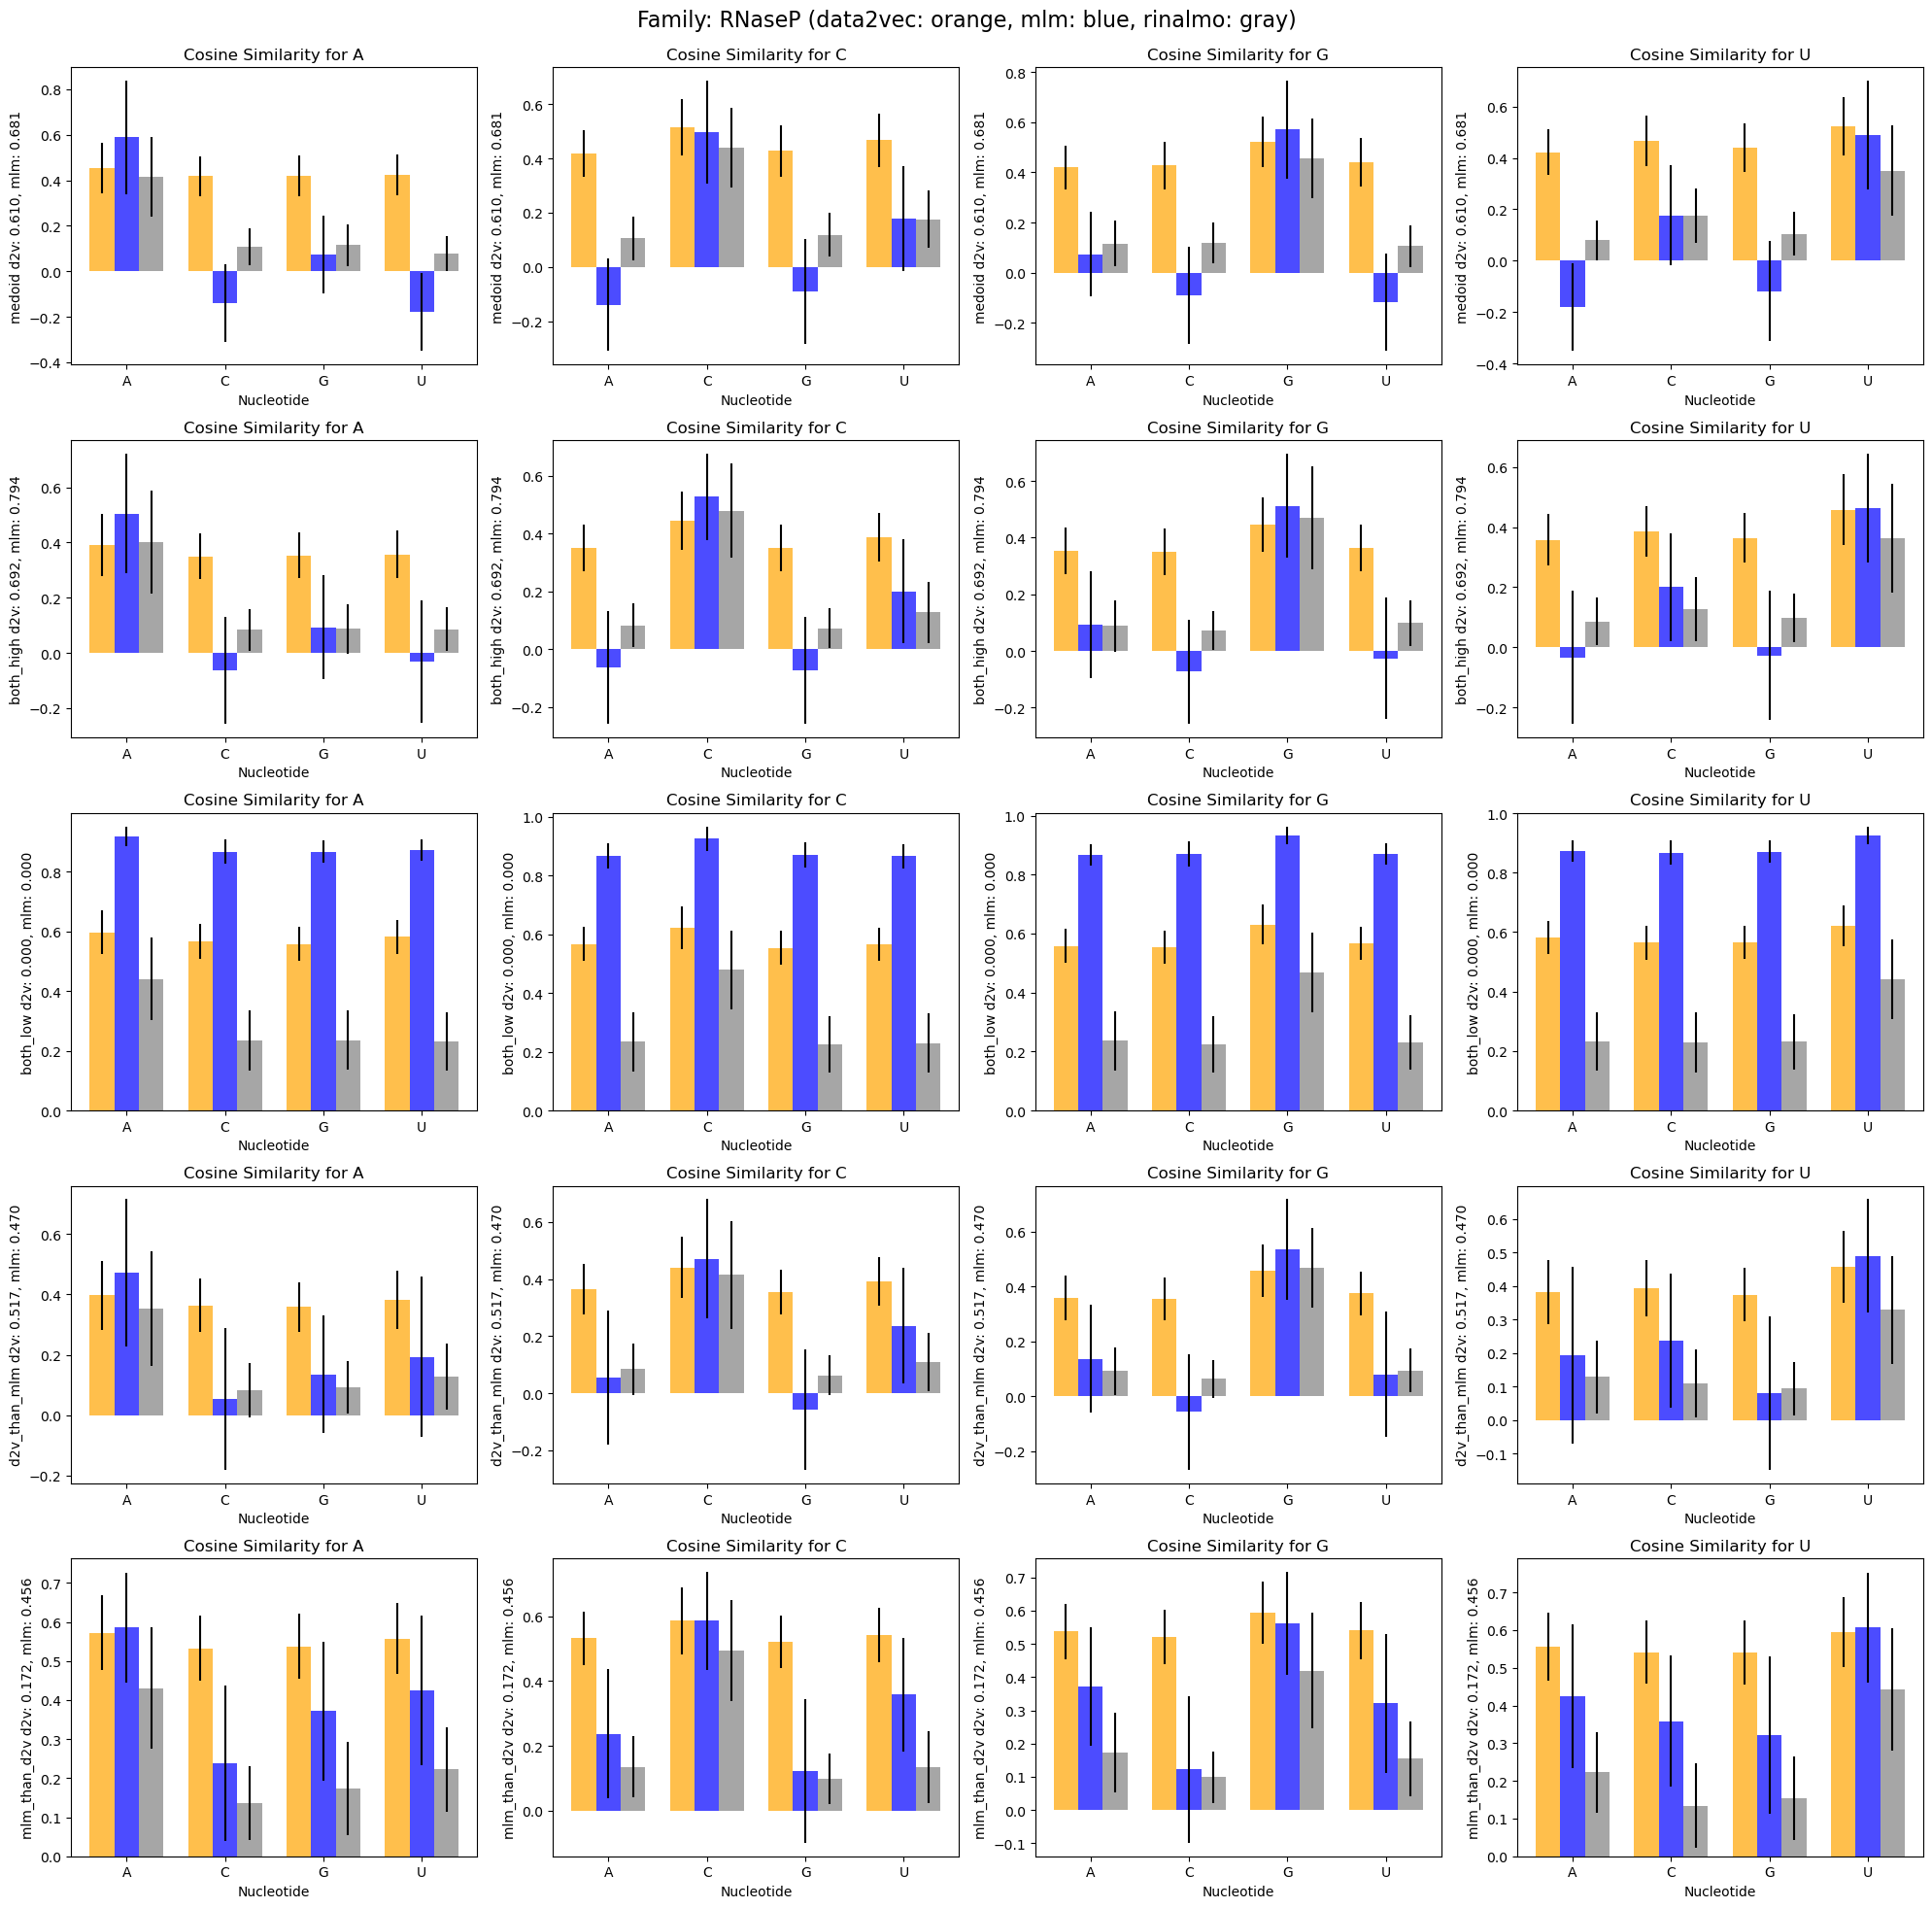

Family: srp_long
  compare_kind: medoid, Sequence ID: srp_Baci.cere._AE017194
  compare_kind: both_high, Sequence ID: srp_Clos.novy._CP000382
  compare_kind: both_low, Sequence ID: srp_Popu.bals._GSP-73824
  compare_kind: d2v_than_mlm, Sequence ID: srp_Zygo.roux._BN000170
  compare_kind: mlm_than_d2v, Sequence ID: srp_List.mono._AE017262


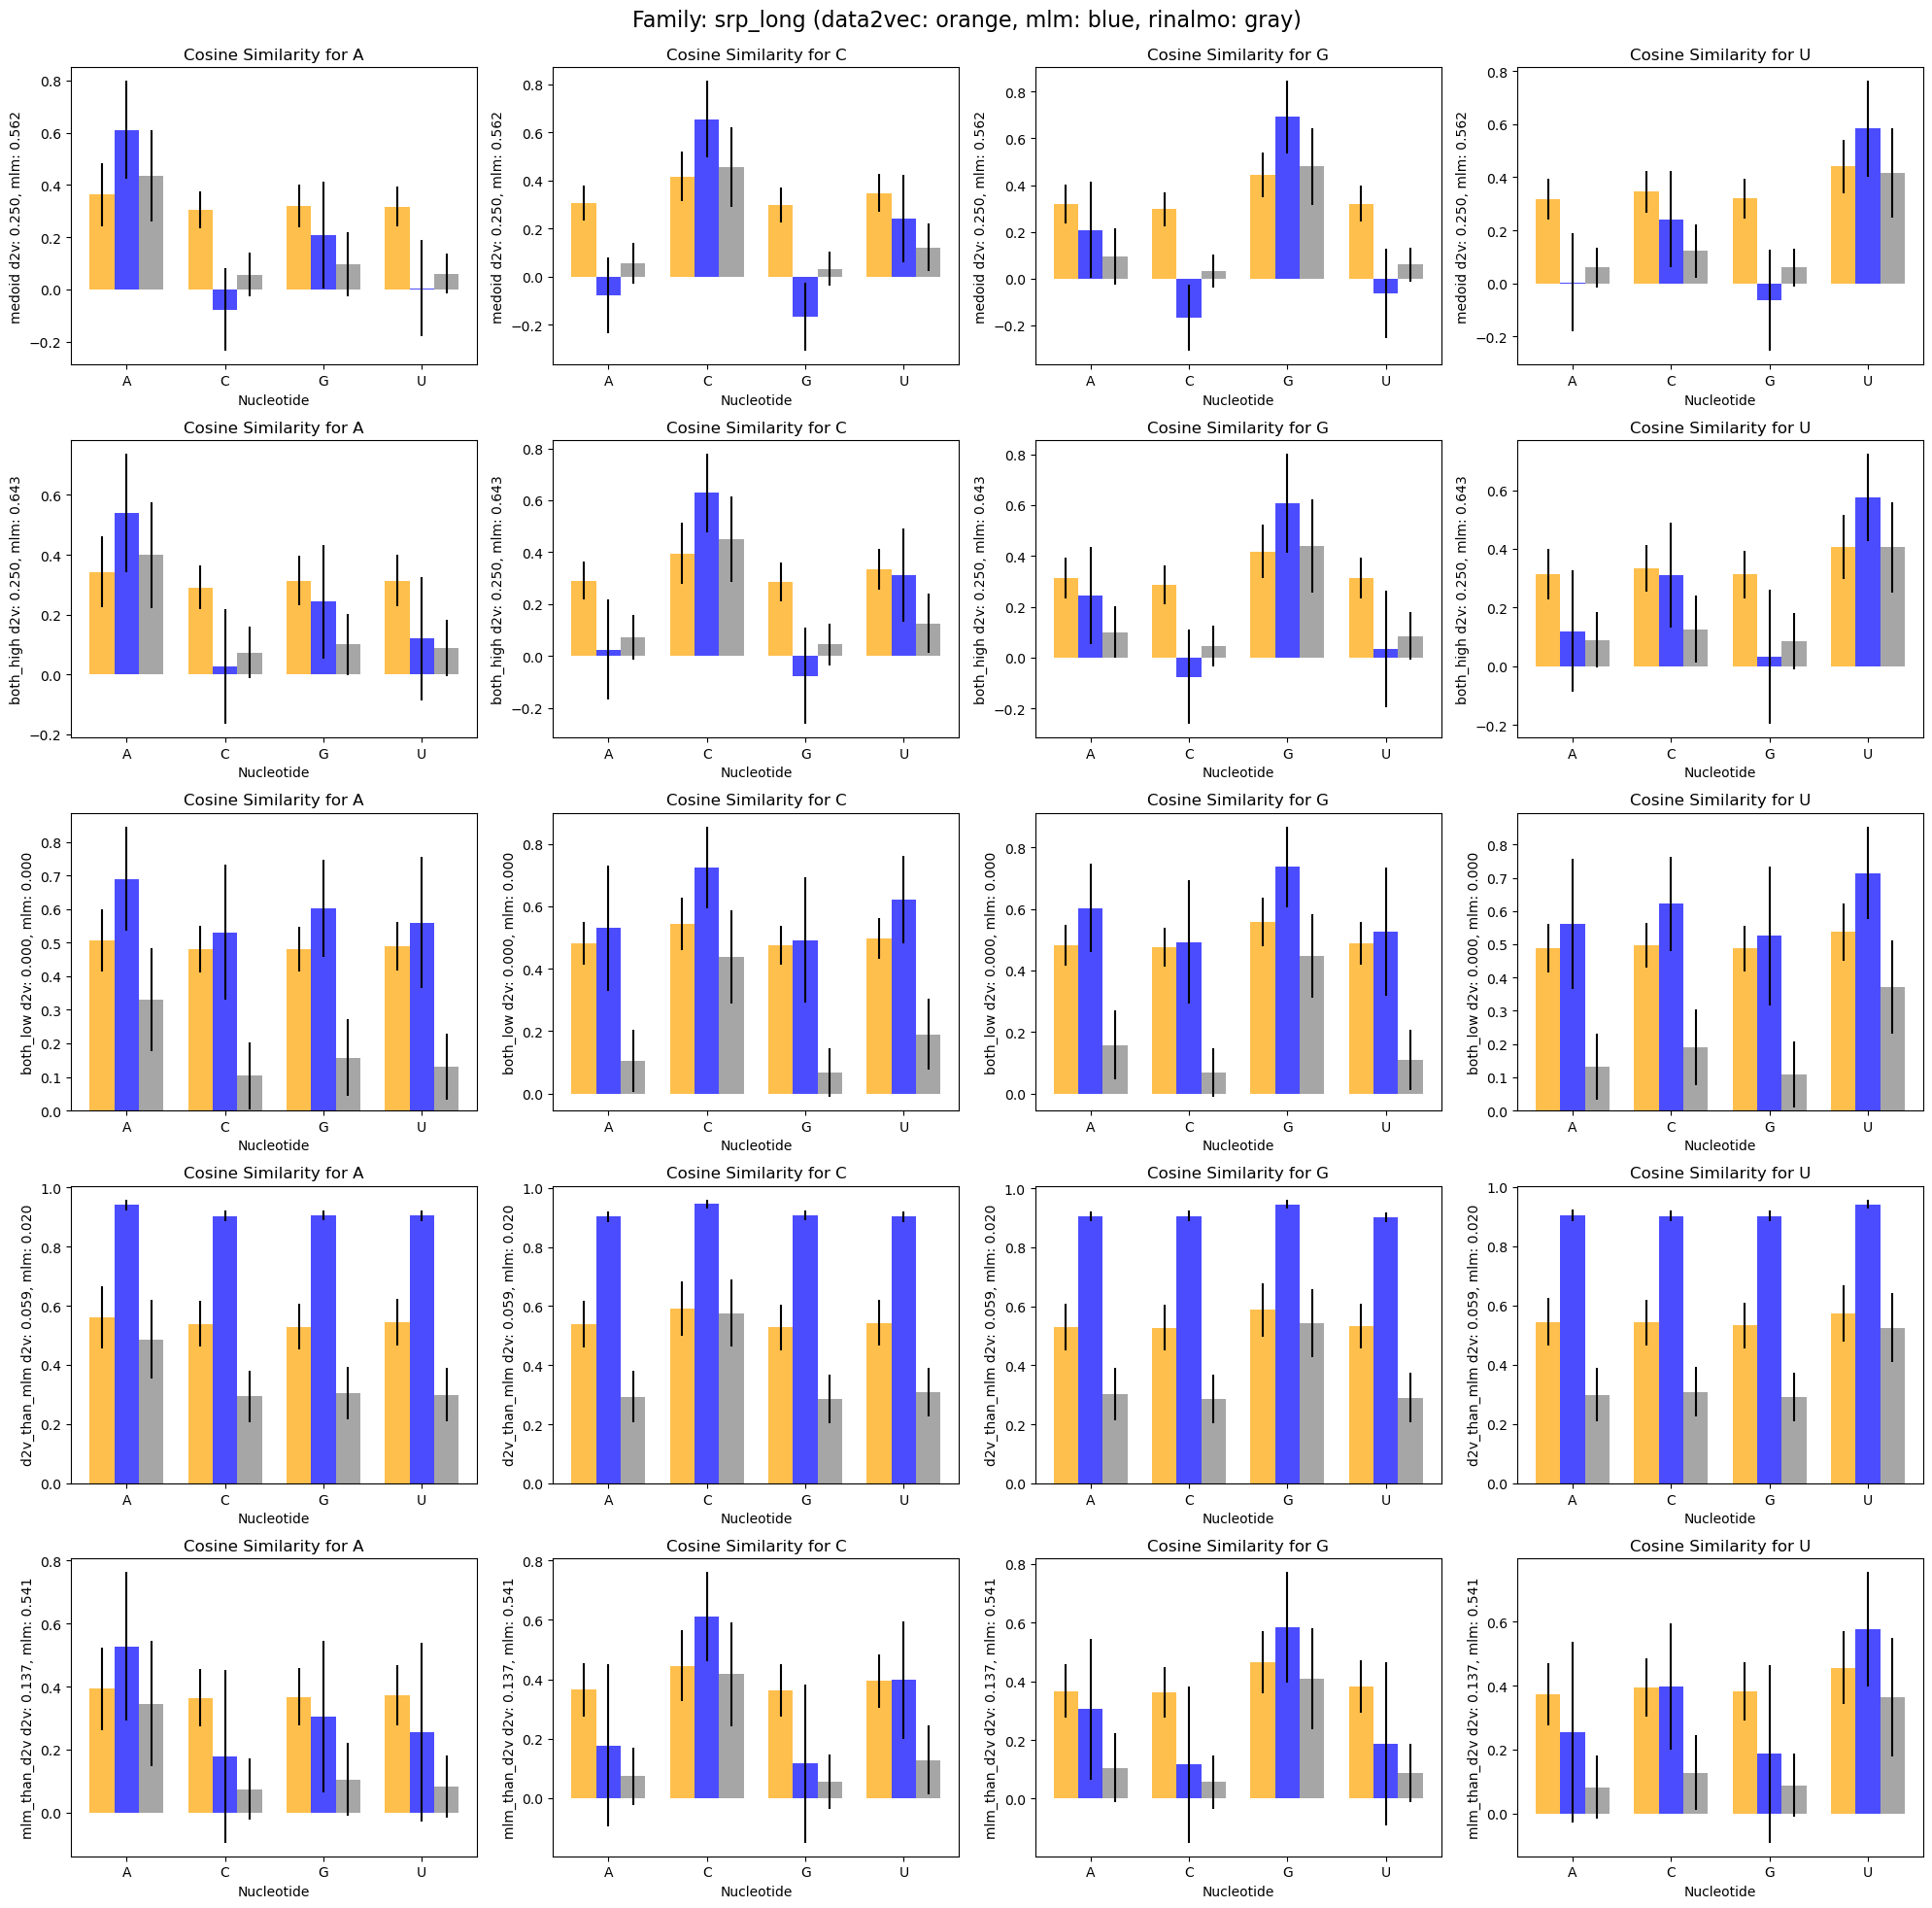

Family: srp_short
  compare_kind: medoid, Sequence ID: srp_Micr.lyso._M31831
  compare_kind: both_high, Sequence ID: srp_Sili.pome._CP000031
  compare_kind: both_low, Sequence ID: srp_Micr.lyso._M31831
  compare_kind: d2v_than_mlm, Sequence ID: srp_Myco.hyop._AE017244
  compare_kind: mlm_than_d2v, Sequence ID: srp_Lact.brev._CP000416


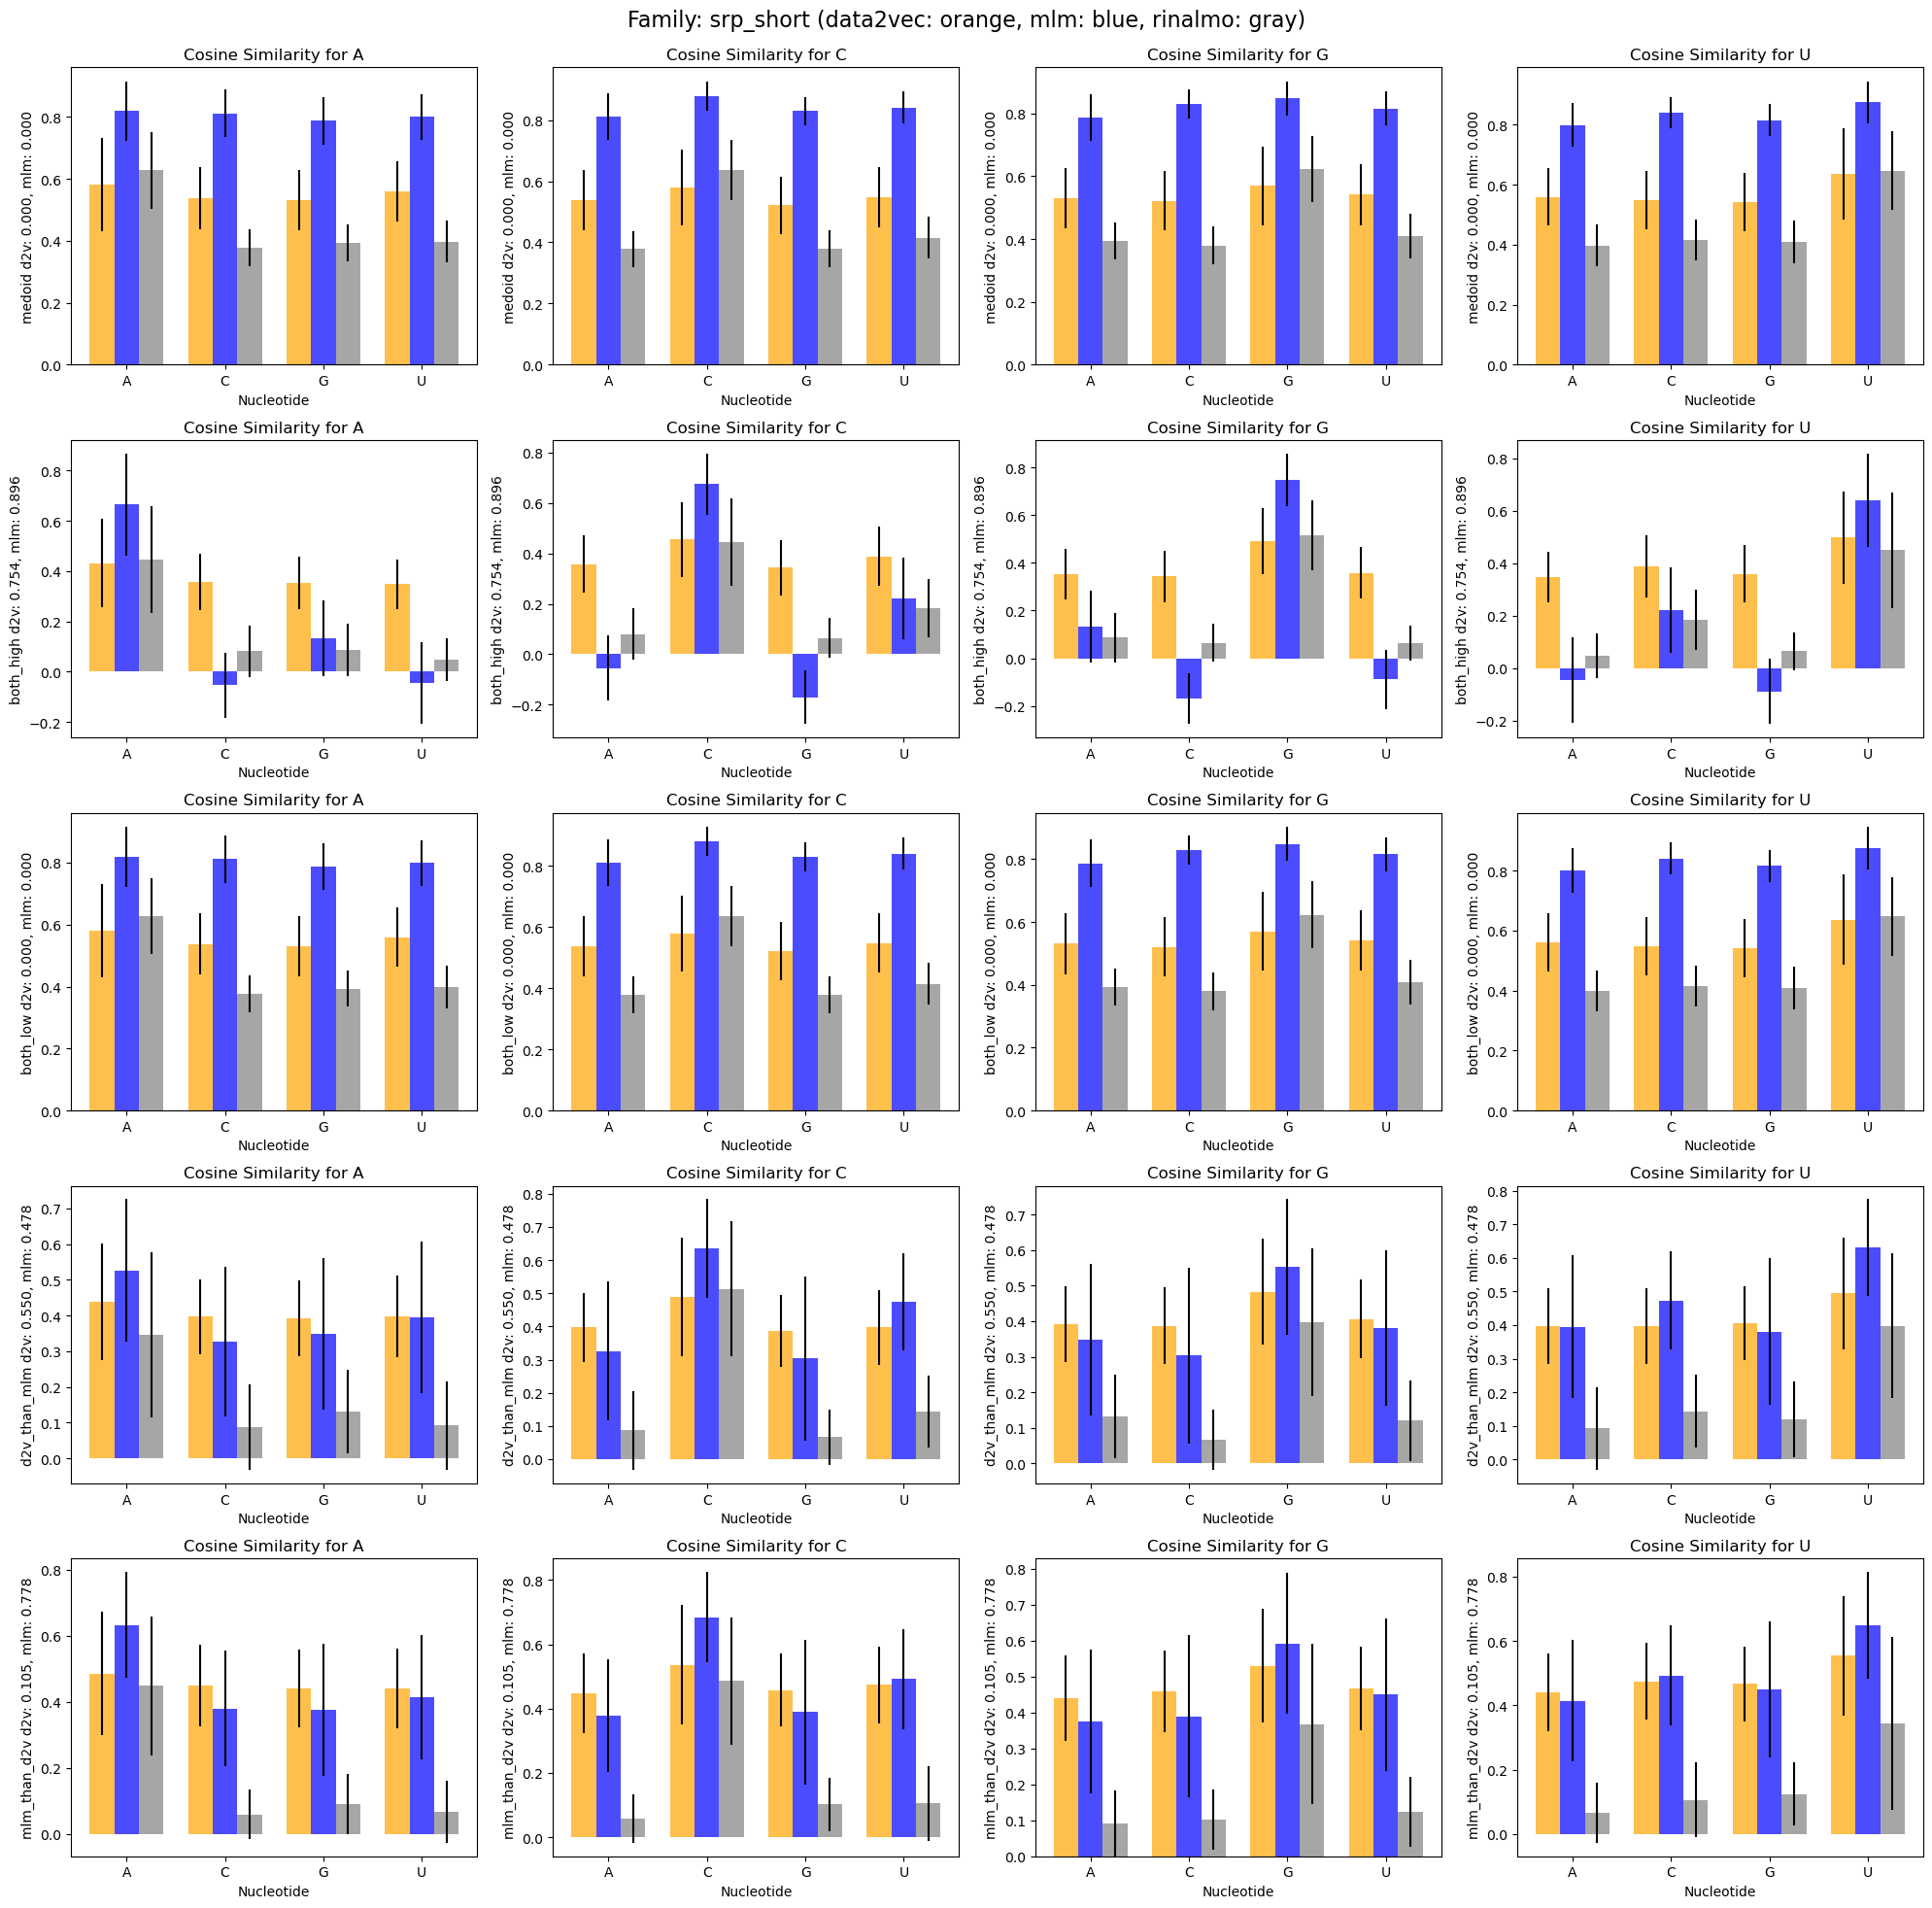

Family: telomerase
  compare_kind: medoid, Sequence ID: telomerase_AC121792.109554-109950
  compare_kind: both_high, Sequence ID: telomerase_AF221924.105-538
  compare_kind: both_low, Sequence ID: telomerase_AF221906.96-545
  compare_kind: d2v_than_mlm, Sequence ID: telomerase_AF221919.107-614
  compare_kind: mlm_than_d2v, Sequence ID: telomerase_AF221924.105-538


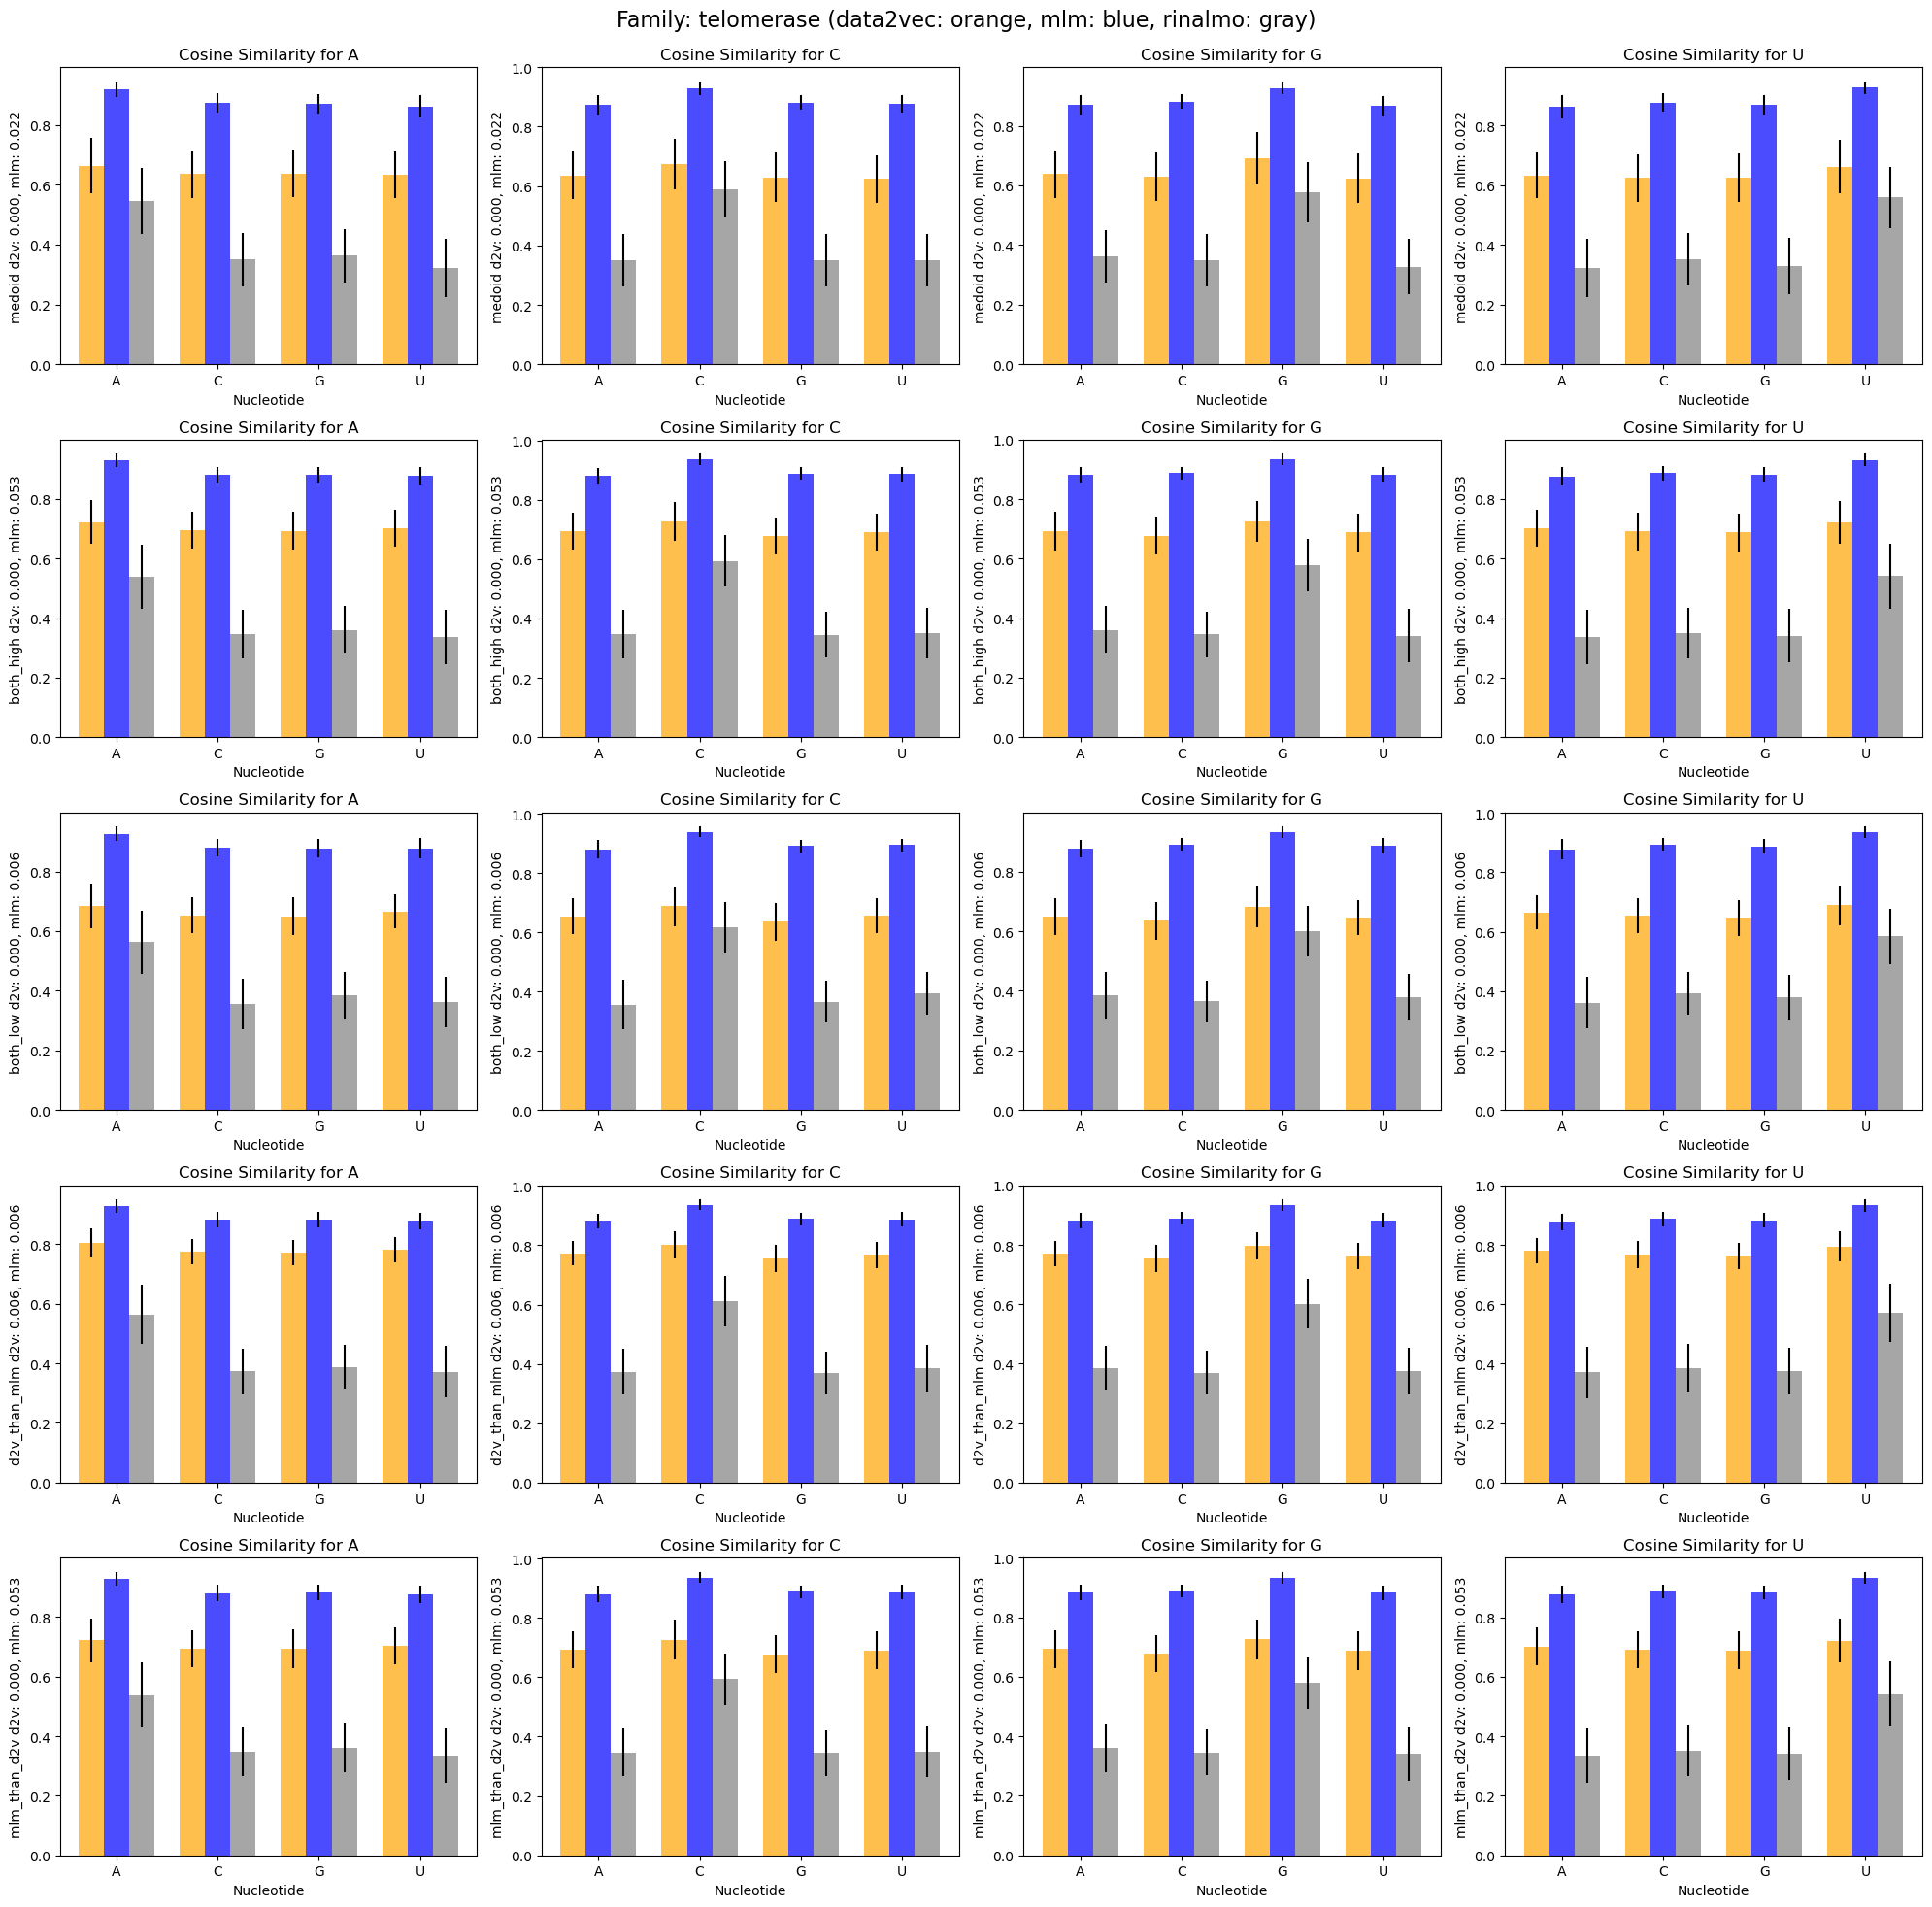

Family: tmRNA
  compare_kind: medoid, Sequence ID: tmRNA_Heli.pylo._AE001503_1-383
  compare_kind: both_high, Sequence ID: tmRNA_Stre.pyog._TRW-1314-1_1-348
  compare_kind: both_low, Sequence ID: tmRNA_Jako.libe._TRW-143017_1-102
  compare_kind: d2v_than_mlm, Sequence ID: tmRNA_Cyan.mero._AY286123_1-236
  compare_kind: mlm_than_d2v, Sequence ID: tmRNA_Aste.yell._CP000061_1-426


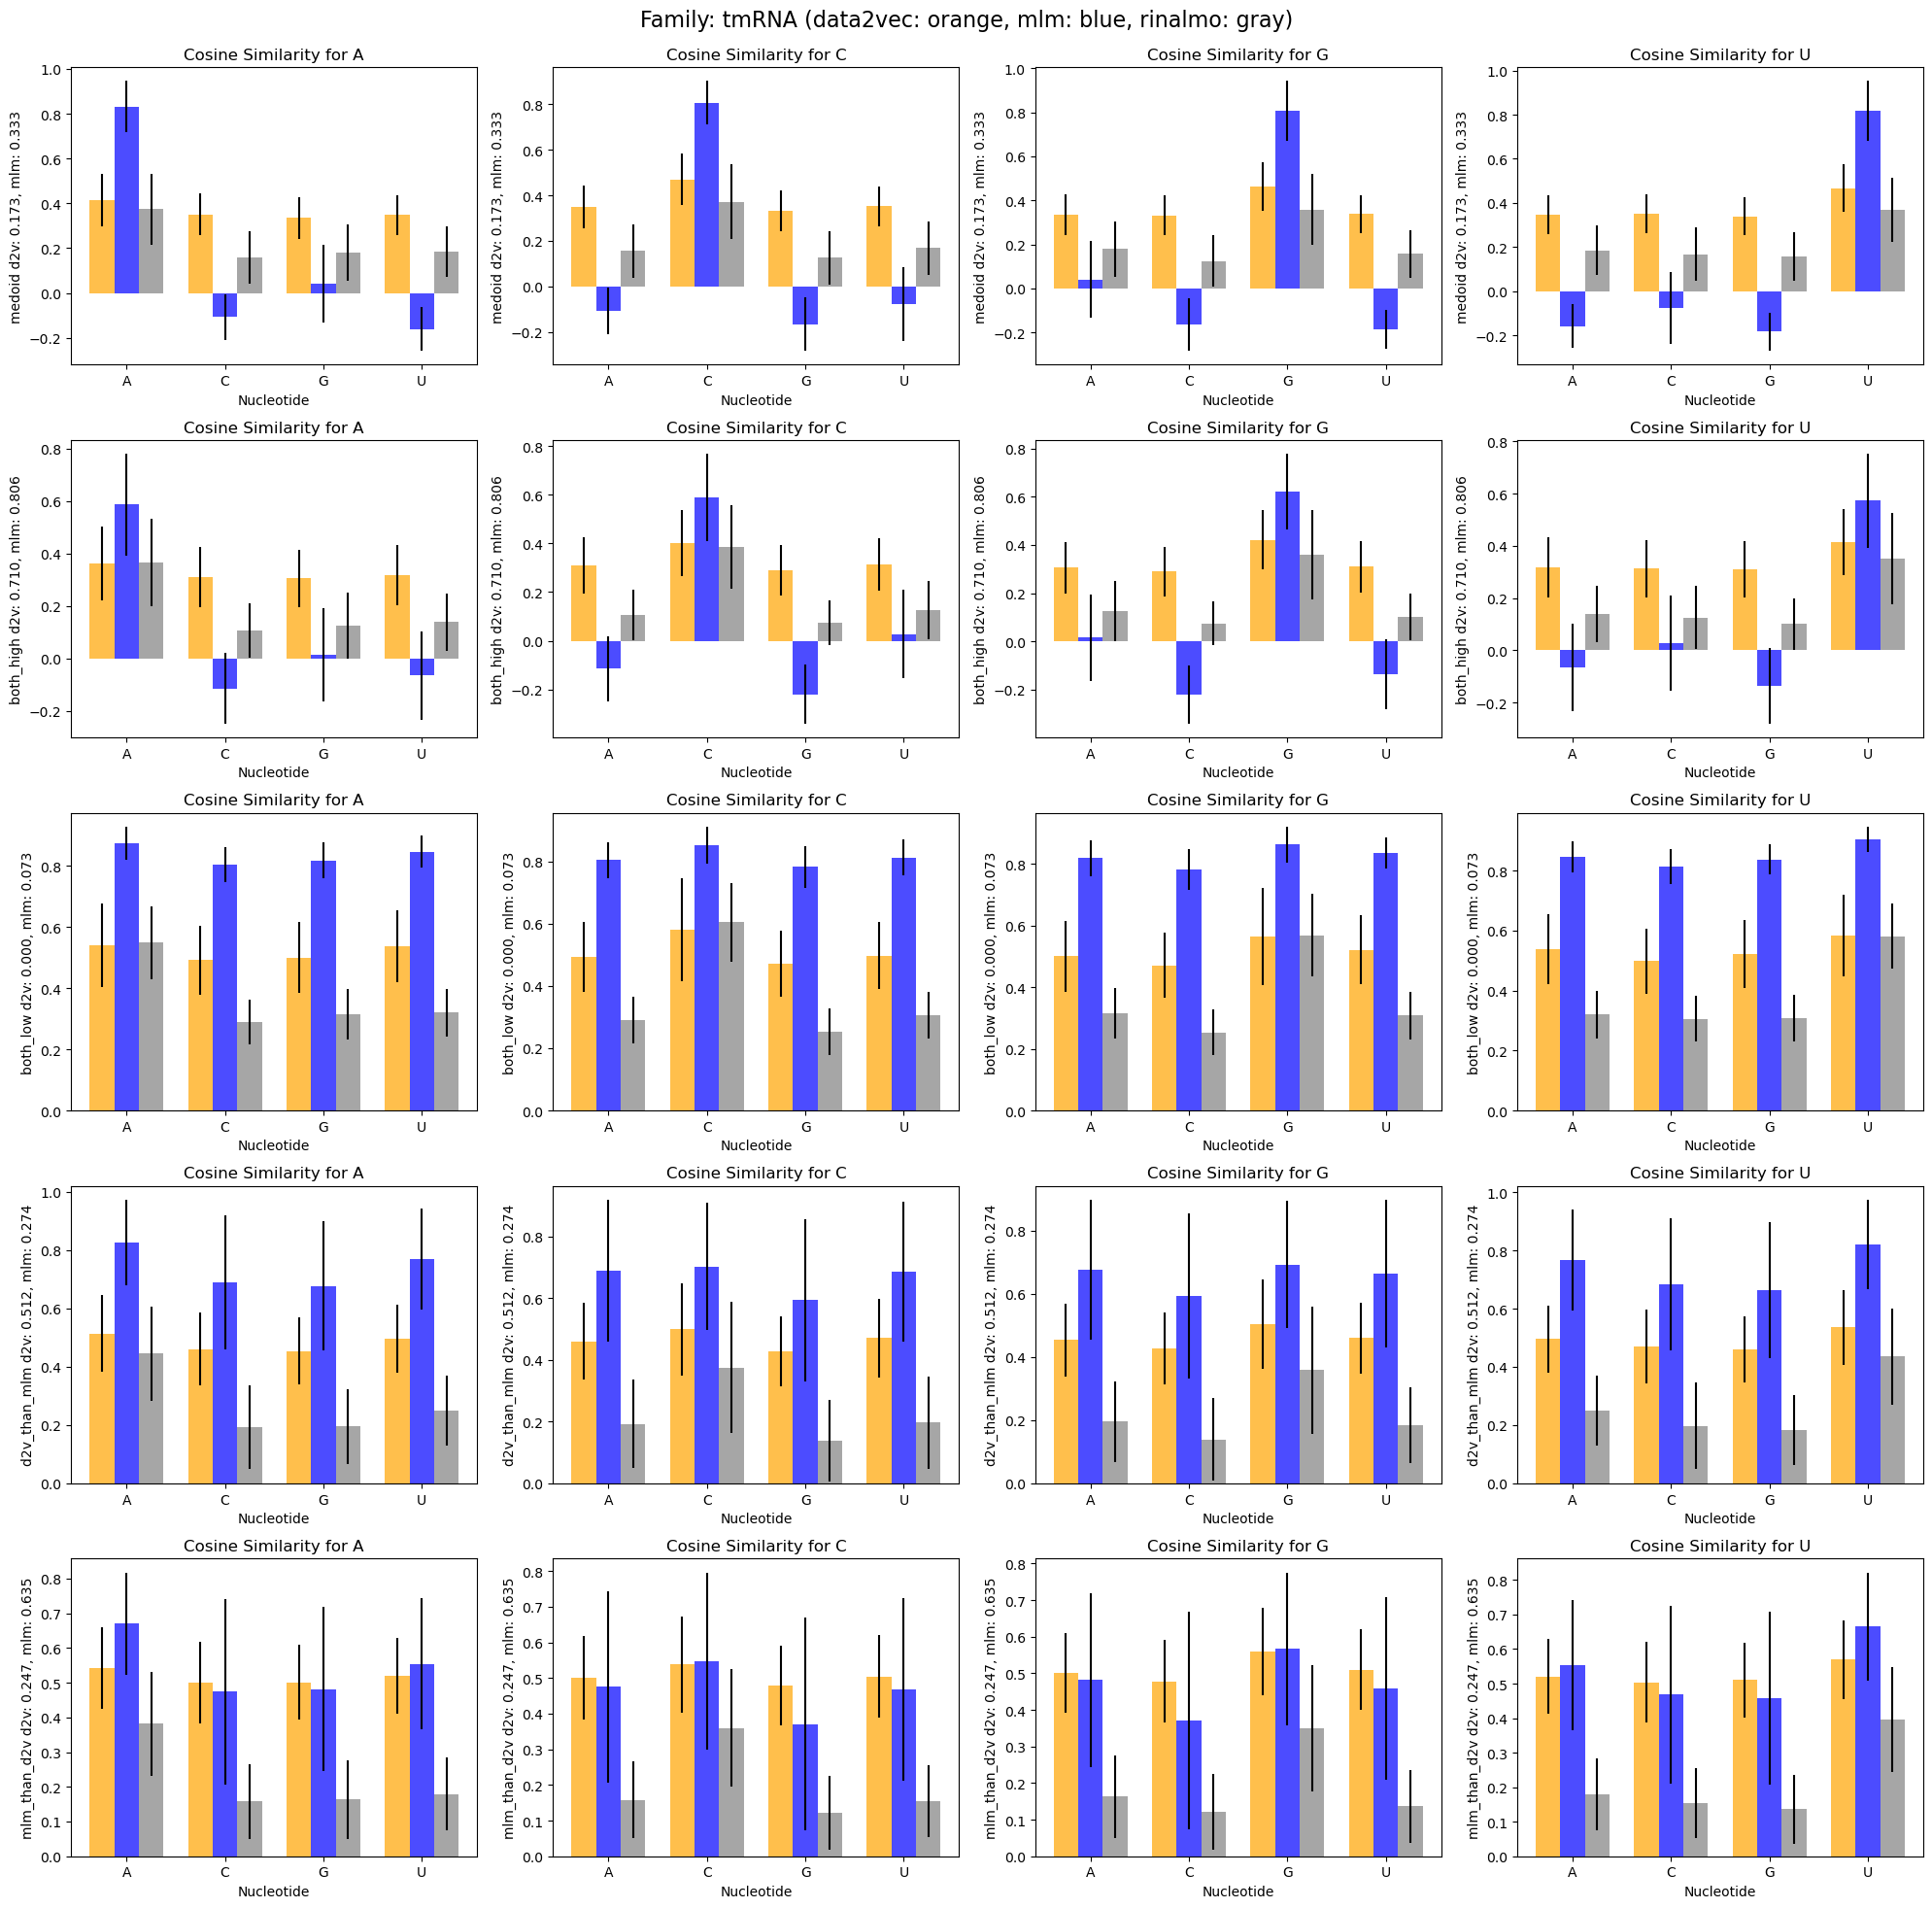

Family: tRNA
  compare_kind: medoid, Sequence ID: tRNA_tdbR00000522-Bos_taurus-9913-Ini-AU
  compare_kind: both_high, Sequence ID: tRNA_tdbR00000362-Saccharomyces_cerevisiae-4932-Arg-NCU
  compare_kind: both_low, Sequence ID: tRNA_tdbR00000363-Ascaris_suum-6253-Arg-PCU
  compare_kind: d2v_than_mlm, Sequence ID: tRNA_tdbR00000475-Mus_musculus-10090-Val-IAC
  compare_kind: mlm_than_d2v, Sequence ID: tRNA_tdbR00000364-Ascaris_suum-6253-Arg-ACG


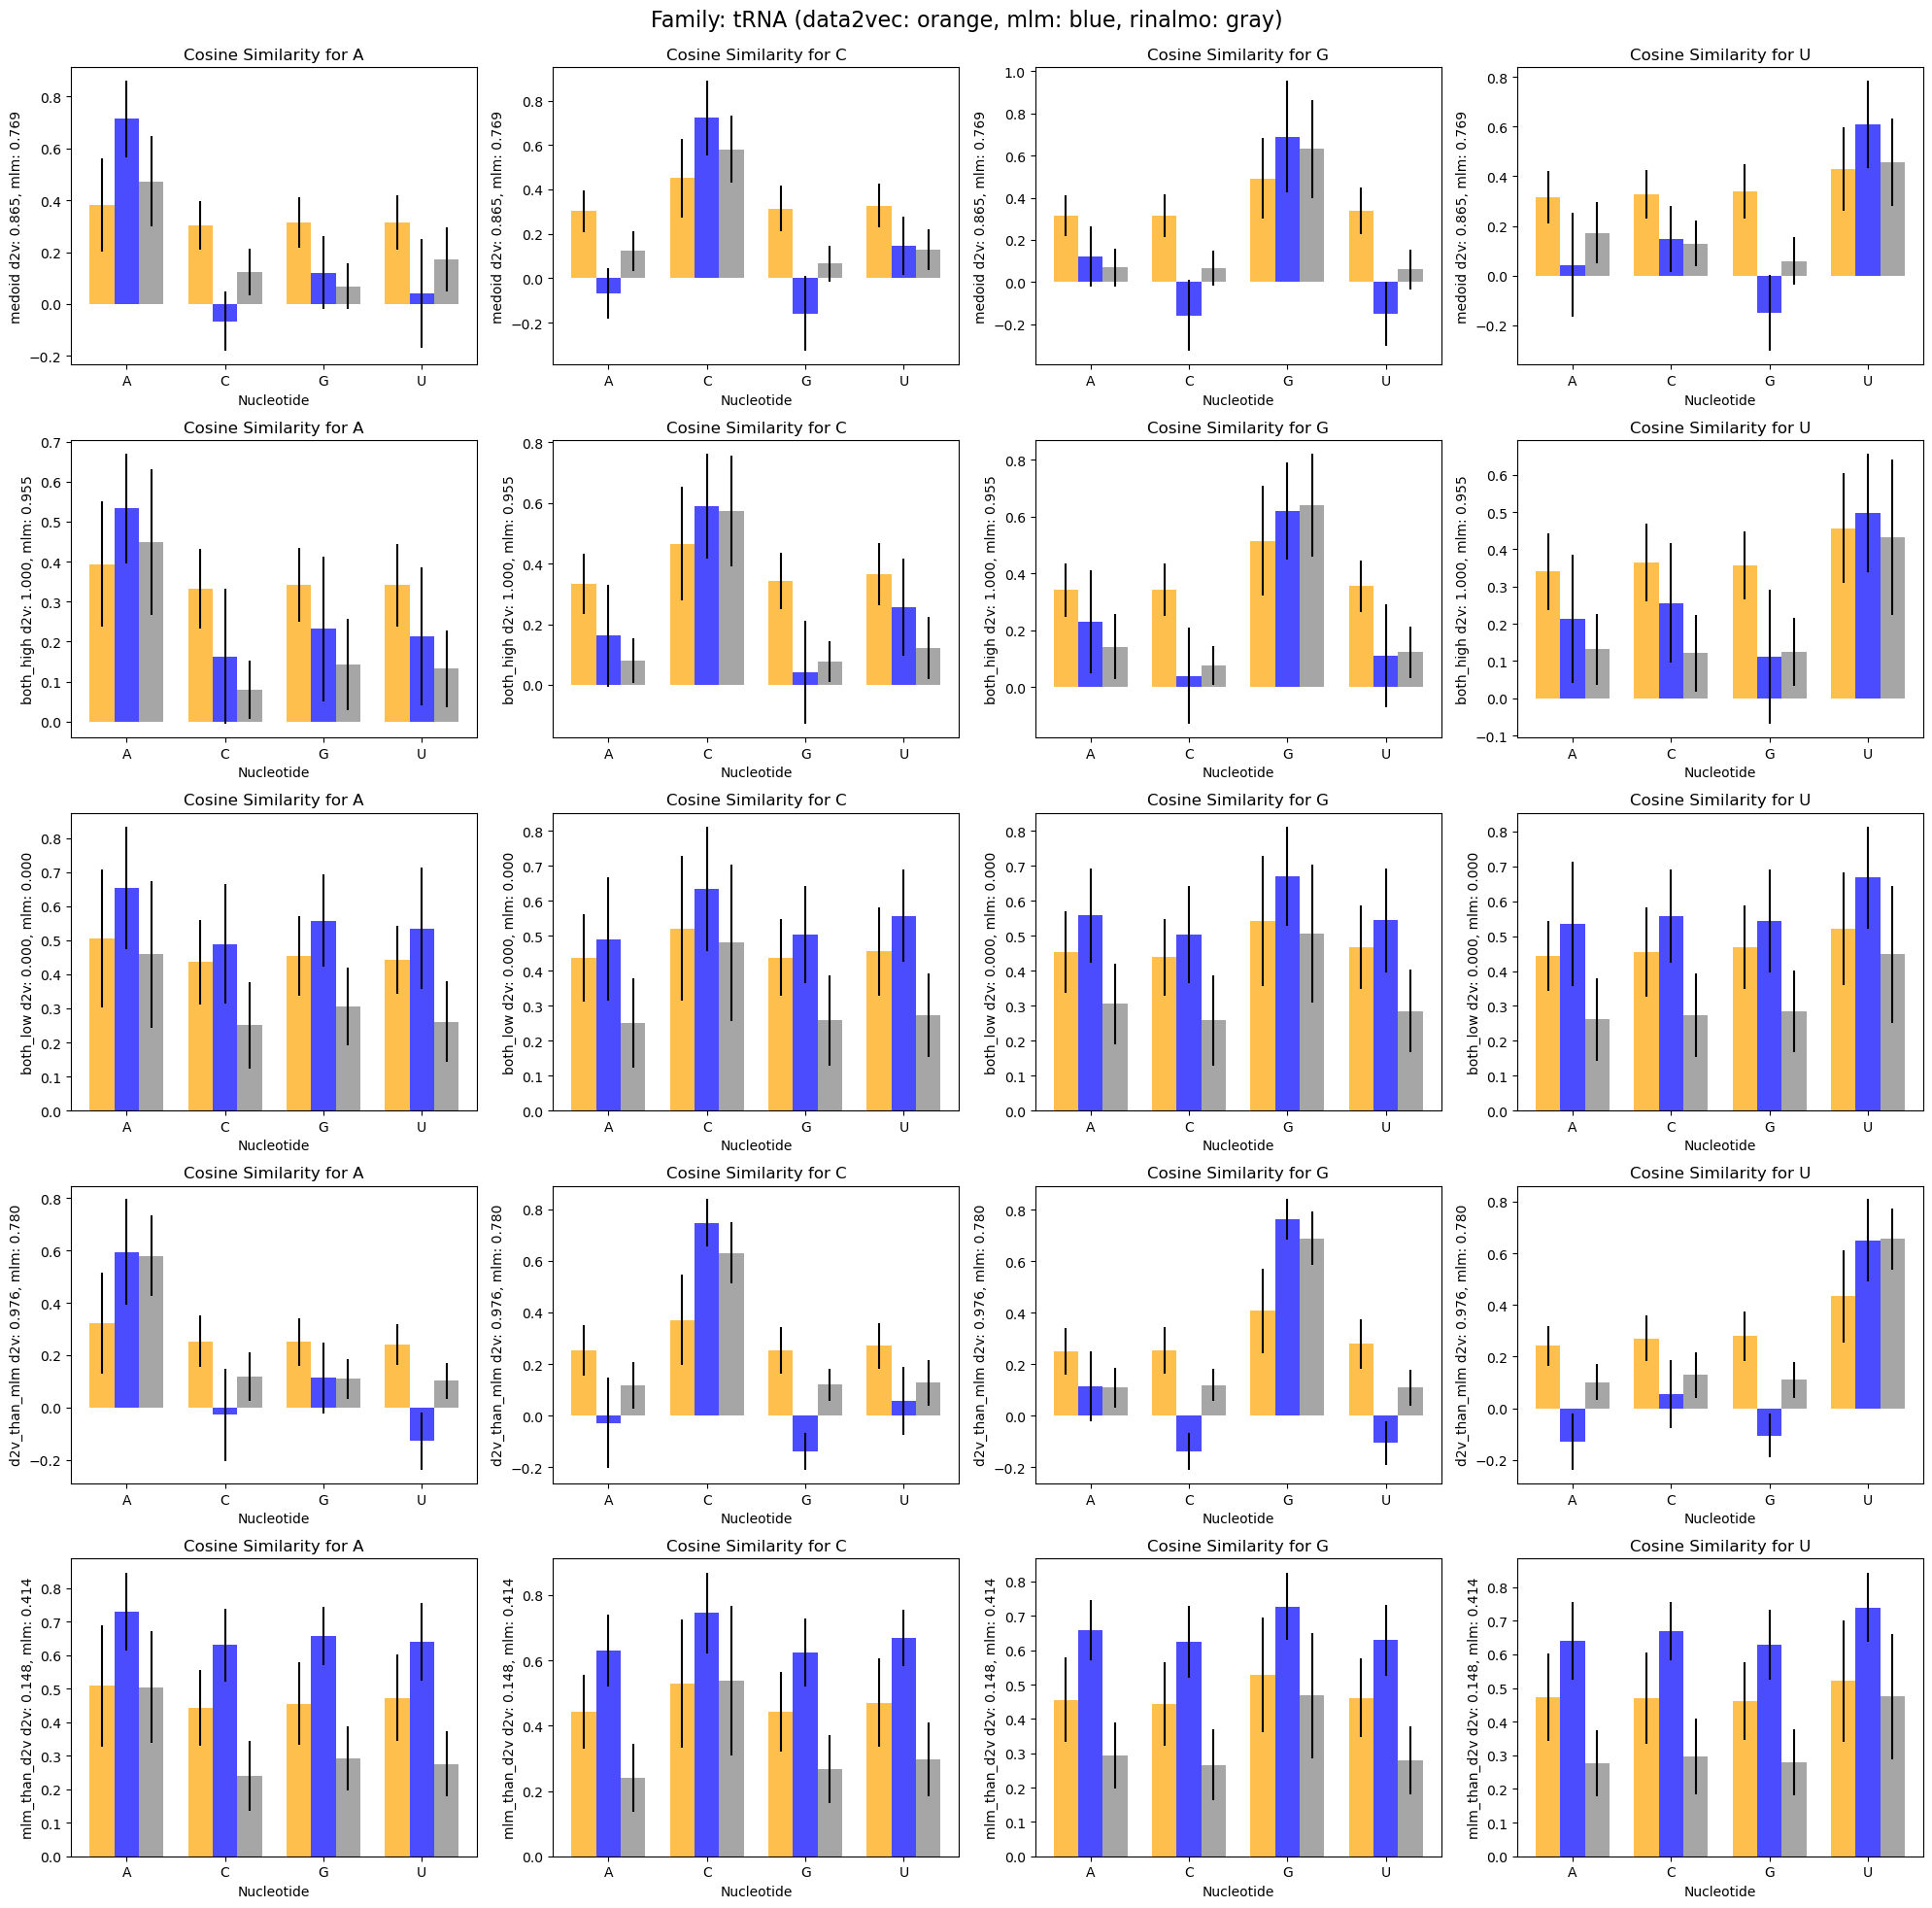

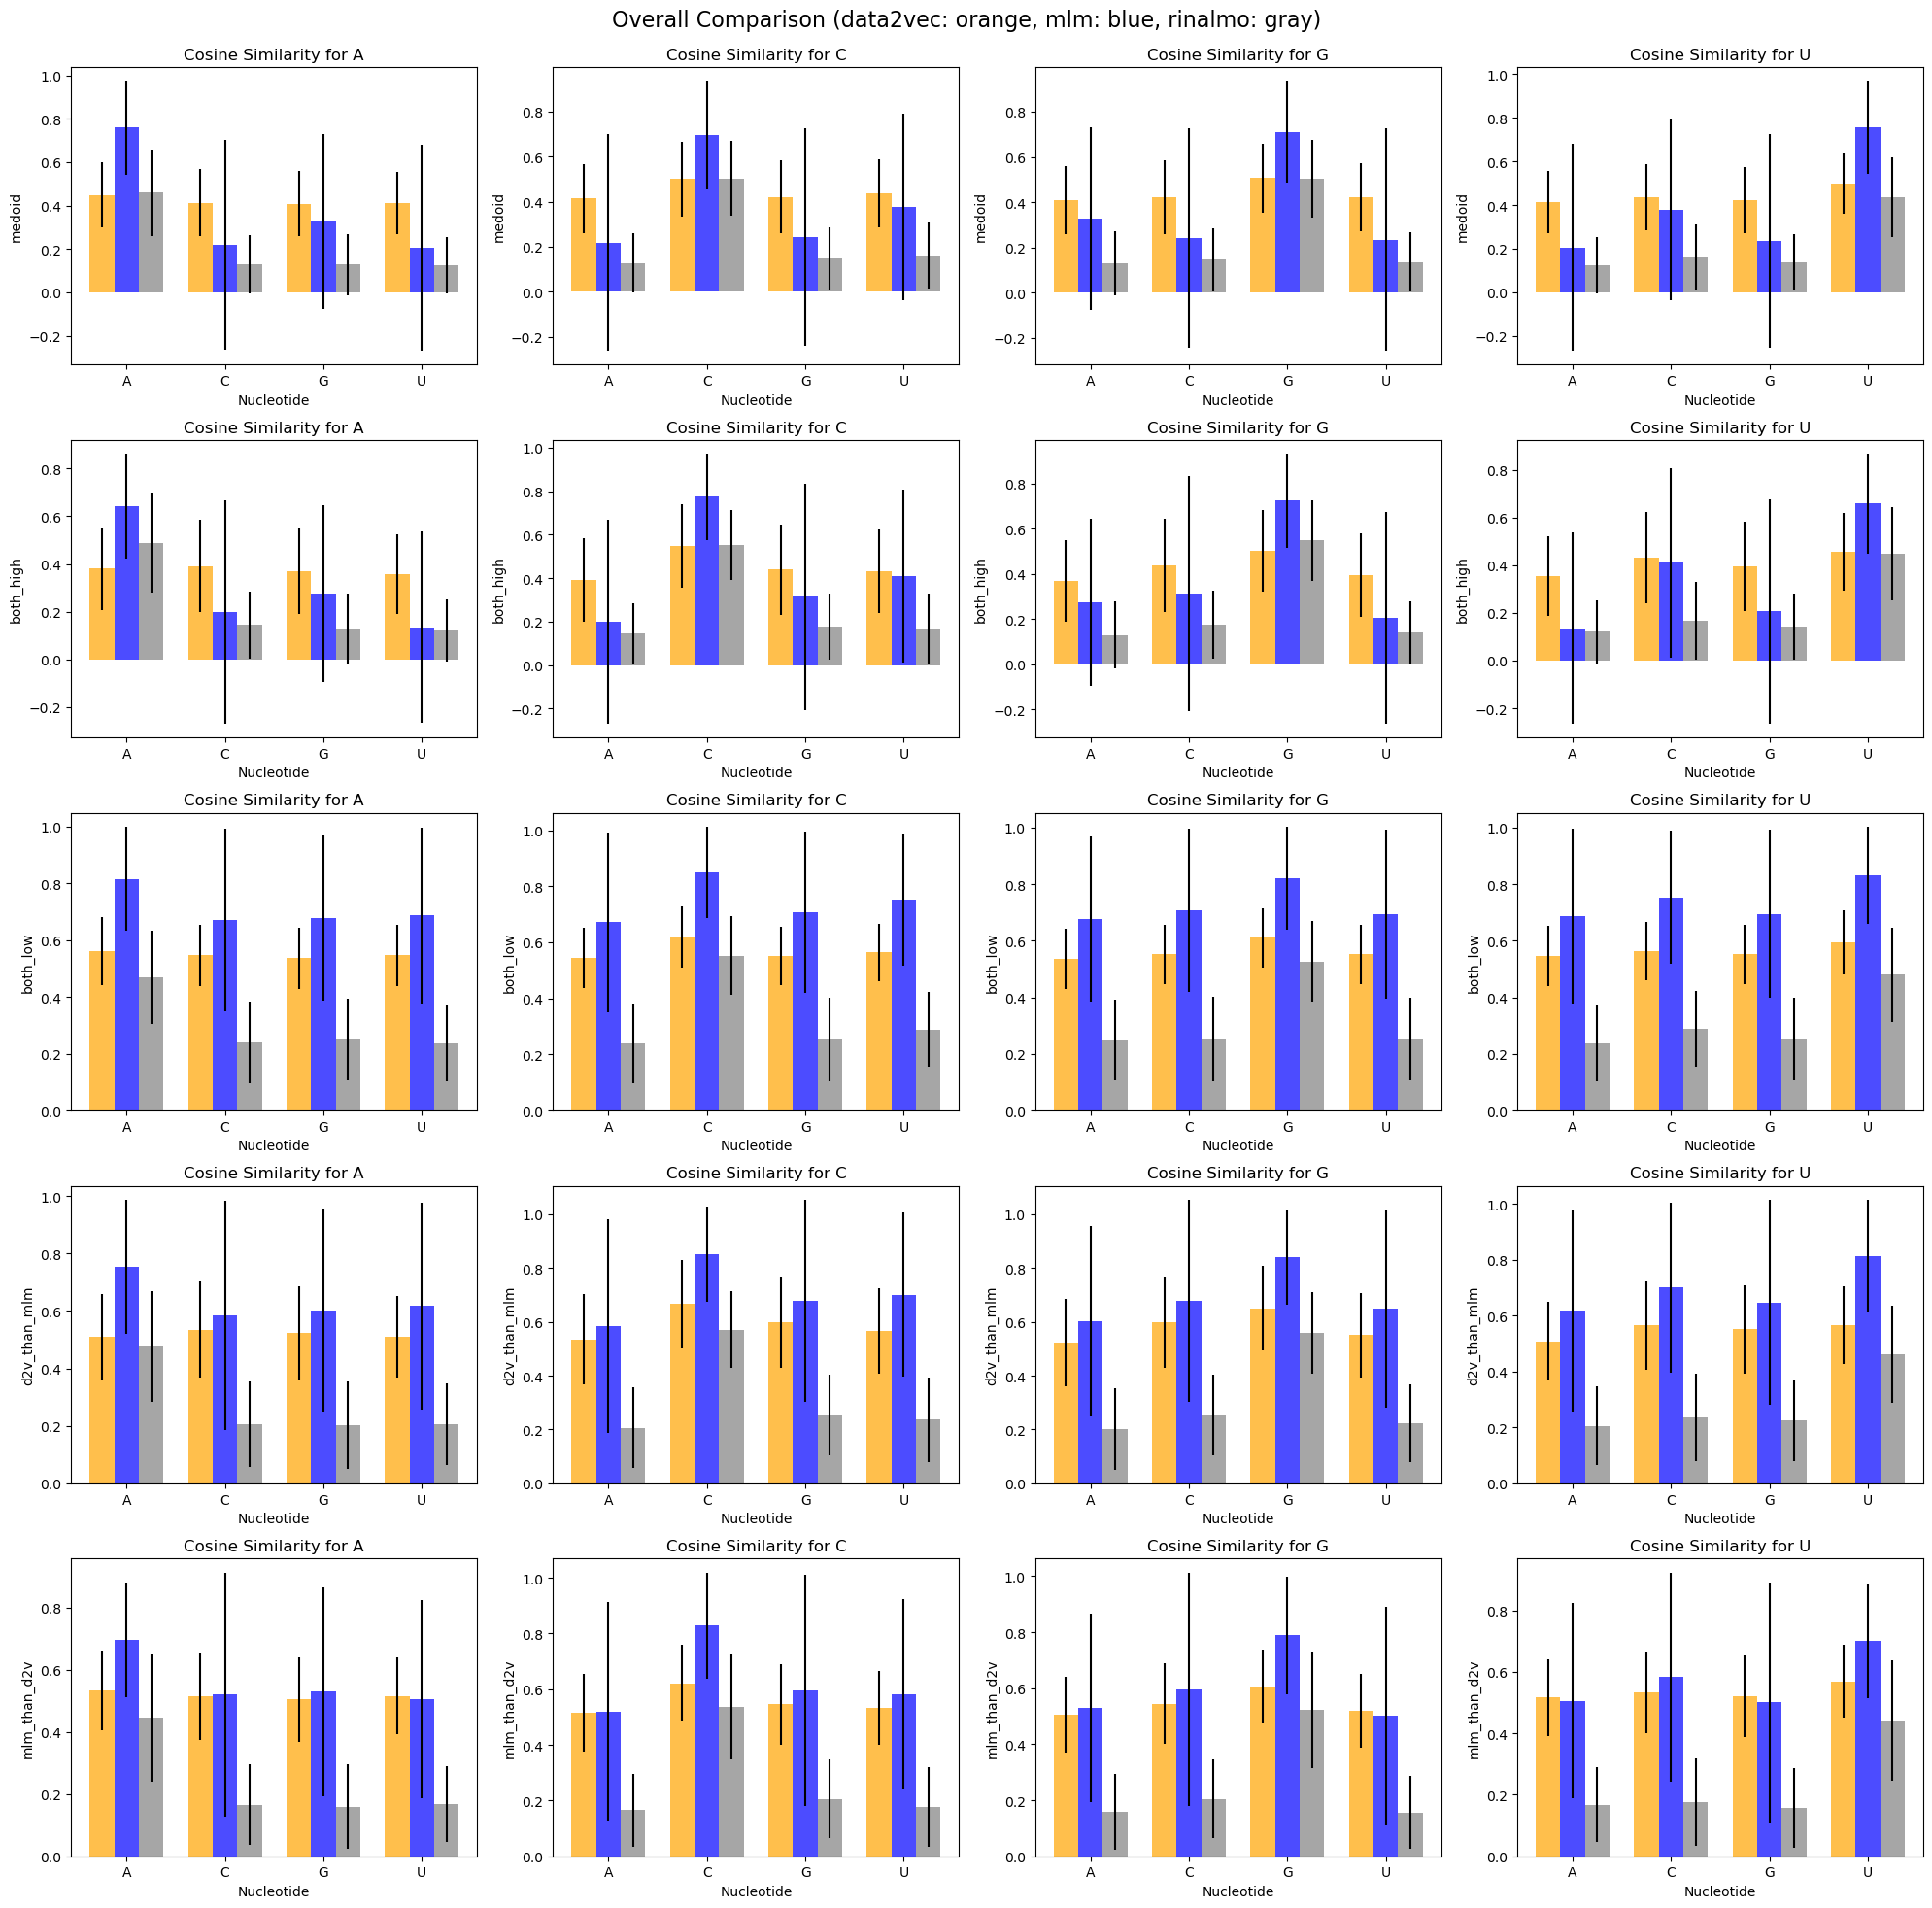

In [ ]:
# ファミリーごとに選ばれた配列について，A, C, G, T のそれぞれの塩基の表現が，他の塩基とどの程度似ているかを計算する

all_results = {
    framework_name: {
        nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
    }
    for framework_name in frameworks
}
for fam in family:
    print(f"Family: {fam}")
    fig, axes = plt.subplots(1, 4, figsize=(4, 20))  # (compare_kinds, nucleotides)
    x = np.arange(len(nucleotides)) * (1.0 + 0.125 * (len(frameworks) - 3))
    width_base = 0.25
    width = width_base * len(frameworks)

    for framework_name in frameworks:
        rep = family_representatives[framework_name][fam][
            "representation"
        ]
        seq = family_representatives[framework_name][fam]["sequence"]

        nt_comparison = {
            nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
        }

        seq_token = torch.tensor(
            [nucleotides.index(nt) for nt in seq],
            dtype=torch.uint8,
            requires_grad=False,
        )

        for i, nt in enumerate(seq):
            # 現在の塩基の表現
            current_rep = rep[i]
            # 他の塩基の表現との類似度を計算 (コサイン類似度のみ)

            cosine_similarities = torch.nn.functional.cosine_similarity(
                current_rep.unsqueeze(0), rep, dim=1
            ).requires_grad_(False)

            for idx, nucleotide in enumerate(nucleotides):
                nt_comparison[nt][nucleotide].append(
                    cosine_similarities[torch.where(seq_token == idx)]
                )

        for idx, nt in enumerate(nucleotides):
            for idx2, nt2 in enumerate(nucleotides):
                nt_comparison[nt][nt2] = torch.cat(nt_comparison[nt][nt2]).numpy()

                all_results[framework_name][nt][nt2].append(
                    nt_comparison[nt][nt2]
                )

                mean_cosine_similarity = np.mean(nt_comparison[nt][nt2])

                std_cosine_similarity = np.std(nt_comparison[nt][nt2])

                # コサイン類似度の結果ごとに, frameworkを棒グラフで重ねて図示
                coodinate = -width_base * (
                    (len(frameworks) - 1) / 2
                ) + width_base * frameworks.index(framework_name)

                axes[0, idx].bar(
                    x[idx2] + coodinate,
                    mean_cosine_similarity,
                    width=width_base,
                    yerr=std_cosine_similarity,
                    alpha=0.7,
                    color=framework_colors[framework_name],
                )

            axes[0, idx].set_title(f"Cosine Similarity for {nt}")
            axes[0, idx].set_xlabel("Nucleotide")
            # axes[0, idx].set_ylabel(
            #     f"d2v: {fam_representatives[fam]['data2vec_score']:.3f}, mlm: {fam_representatives[fam]['mlm_score']:.3f}"
            # )
            axes[0, idx].set_xticks(x)
            axes[0, idx].set_xticklabels(nucleotides)

    # 類似度の結果を図示
    plt.suptitle(
        f"Family: {fam} ({', '.join([f'{f}: {framework_colors[f]}' for f in frameworks])})",
        fontsize=16,
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # タイトルとグラフの間隔を調整
    plt.show()


# 全てのファミリーの結果をまとめて図示
# fig, axes = plt.subplots(5, 4, figsize=(20, 20))  # (compare_kinds, nucleotides)
# x = np.arange(len(nucleotides)) * (1.0 + 0.125 * (len(frameworks) - 3))
# width = width_base * len(frameworks)
# for compare_idx, compare_kind in enumerate(["medoid"] + list(compare_kinds.keys())):
#     for idx, nt in enumerate(nucleotides):
#         for idx2, nt2 in enumerate(nucleotides):
#             for framework_name in frameworks:
#                 all_results[framework_name][compare_kind][nt][nt2] = np.concatenate(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 mean_cosine_similarity = np.mean(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 std_cosine_similarity = np.std(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 coodinate = -width_base * (
#                     (len(frameworks) - 1) / 2
#                 ) + width_base * frameworks.index(framework_name)
#                 color = framework_colors[framework_name]

#                 axes[compare_idx, idx].bar(
#                     x[idx2] + coodinate,
#                     mean_cosine_similarity,
#                     width=width_base,
#                     yerr=std_cosine_similarity,
#                     alpha=0.7,
#                     color=color,
#                 )

#         axes[compare_idx, idx].set_title(f"Cosine Similarity for {nt}")
#         axes[compare_idx, idx].set_xlabel("Nucleotide")
#         axes[compare_idx, idx].set_ylabel(f"{compare_kind}")
#         axes[compare_idx, idx].set_xticks(x)
#         axes[compare_idx, idx].set_xticklabels(nucleotides)


# plt.suptitle(
#     f"Overall Comparison ({', '.join([f'{f}: {framework_colors[f]}' for f in frameworks])})",
#     fontsize=16,
# )
# plt.tight_layout()
# plt.subplots_adjust(top=0.95)  # タイトルとグラフの間隔を調整
# plt.show()

Framework: data2vec
  Correlation between similarity and F1 score: 0.725
  Regression line: y = 8.672x + -0.310
Framework: mlm
  Correlation between similarity and F1 score: 0.733
  Regression line: y = 0.828x + 0.109


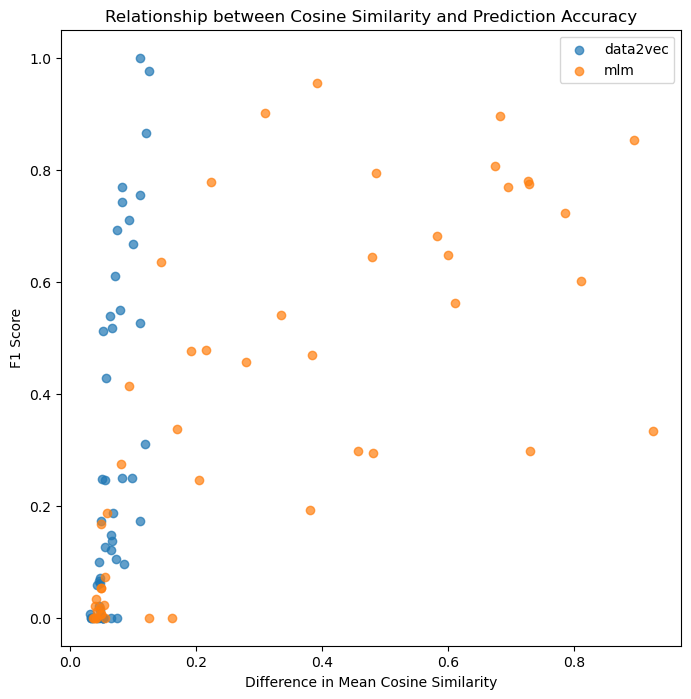

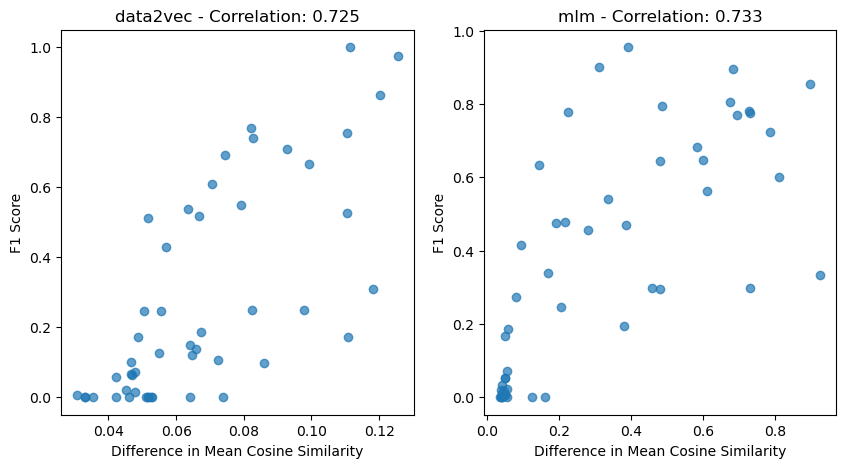

In [25]:
# 各配列について，ACGUに対応する類似度の分散と，その配列の予測精度との関係を散布図で示す
frameworks = ["data2vec", "mlm"]

fig, axes = plt.subplots(figsize=(8, 8))
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
for framework_idx, framework_name in enumerate(frameworks):
    print(f"Framework: {framework_name}")
    output_similarity = []
    output_f1_score = []
    for fam in family:
        for compare_idx, compare_kind in enumerate(
            ["medoid"] + list(compare_kinds.keys())
        ):
            rep = family_representatives[framework_name][fam][compare_kind][
                "representation"
            ]
            seq = family_representatives[framework_name][fam][compare_kind]["sequence"]

            nt_comparison = {
                nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
            }

            seq_token = torch.tensor(
                [nucleotides.index(nt) for nt in seq],
                dtype=torch.uint8,
                requires_grad=False,
            )

            for i, nt in enumerate(seq):
                # 現在の塩基の表現
                current_rep = rep[i]
                # 他の塩基の表現との類似度を計算 (コサイン類似度のみ)

                cosine_similarities = torch.nn.functional.cosine_similarity(
                    current_rep.unsqueeze(0), rep, dim=1
                ).requires_grad_(False)

                for idx, nucleotide in enumerate(nucleotides):
                    nt_comparison[nt][nucleotide].append(
                        cosine_similarities[torch.where(seq_token == idx)]
                    )

            diff_mean_cosine_similarity = []
            for idx, nt in enumerate(nucleotides):
                nt_mean_cosine_similarity = 0.0
                other_mean_cosine_similarity = 0.0
                for idx2, nt2 in enumerate(nucleotides):
                    nt_comparison[nt][nt2] = torch.cat(nt_comparison[nt][nt2]).numpy()
                    if nt == nt2:
                        nt_mean_cosine_similarity += np.mean(nt_comparison[nt][nt2])
                    else:
                        other_mean_cosine_similarity += np.mean(nt_comparison[nt][nt2])

                other_mean_cosine_similarity /= len(nucleotides) - 1
                diff_mean_cosine_similarity.append(
                    nt_mean_cosine_similarity - other_mean_cosine_similarity
                )

            output_similarity.append(np.mean(np.array(diff_mean_cosine_similarity)))
            output_f1_score.append(
                fam_representatives[fam][compare_kind][f"{framework_name}_score"]
            )

    axes.scatter(
        output_similarity,
        output_f1_score,
        label=f"{framework_name}",
        alpha=0.7,
    )

    # 相関係数の計算と表示
    correlation = np.corrcoef(output_similarity, output_f1_score)[0, 1]

    # 散布図に回帰直線の計算と表示
    m, b = np.polyfit(output_similarity, output_f1_score, 1)
    # axes2[framework_idx].plot(
    #     output_similarity,
    #     m * np.array(output_similarity) + b,
    #     color="gray",
    #     label=f"Regression Line (r={correlation:.3f})",
    # )
    print(f"  Correlation between similarity and F1 score: {correlation:.3f}")
    print(f"  Regression line: y = {m:.3f}x + {b:.3f}")

    axes2[framework_idx].scatter(
        output_similarity,
        output_f1_score,
        alpha=0.7,
    )

    axes2[framework_idx].set_xlabel("Difference in Mean Cosine Similarity")
    axes2[framework_idx].set_ylabel("F1 Score")
    axes2[framework_idx].set_title(f"{framework_name} - Correlation: {correlation:.3f}")
    # axes2[framework_idx].legend()

axes.set_xlabel("Difference in Mean Cosine Similarity")
axes.set_ylabel("F1 Score")
axes.set_title("Relationship between Cosine Similarity and Prediction Accuracy")
axes.legend()


plt.show()
